Author(s) : Daniel R., Tarry, Laura Gómez Navarro, Elisabet Verger-Miralles

Objective: Describe xxx

Created on: October 2023

Last updated on:


In [1]:
import time

print(time.ctime(time.time()))

Tue Apr  9 15:58:47 2024


In [2]:
import sys
sys.path.insert(0, "../../processing/")

In [3]:
import os
import numpy as np
import xarray as xr # version 0.20.1 necesarry, 0.16 gives error when calculating u_for
import matplotlib.pyplot as plt
import scipy.signal as signal

import cartopy
import cartopy.crs as ccrs
import cartopy.feature       as cfeature
from cartopy.mpl.gridliner import LongitudeFormatter, LatitudeFormatter

from read_data_tools import latlon2uv_dir

In [4]:
# version_information

In [5]:
print(xr.__version__)

2023.6.0


# Parameters:

In [6]:
url_drifter = "drifter_svpb035-scb_svpb035/L0/2023/dep0001_drifter-svpb035_scb-svpb035_L0_2023-02-20.nc?"

# --> not used because L0 SOCIB give problems, so L0 downloaded directly from NOAA site (see gdocs)
drifter_type = 'S' # C: CARTHE ; H: Hereon ; S: SVP-B 
# n_window = 12 # we leave like this for now

In [7]:
savedir_figs = '../proc_figures/'

# SVP example

# 1. Loading the data:

In [8]:
# Main root
url_root = "http://thredds.socib.es/thredds/dodsC/drifter/surface_drifter/"

In [9]:
# parameters of the thredd file

if drifter_type == 'C':
    url_vars = "trajectory,time[0:1:-1],DEPTH,LAT[0:1:-1],LON[0:1:-1],BAT_STATUS[0:1:-1]"
    temp_res = 600. # Specifying seconds 
    # Step depending on drifter (CARTHE and HEREON 600s (10 mins (we choose the highest time resolution)) 
elif drifter_type == 'H':
    url_vars = "trajectory,time[0:1:-1],LAT[0:1:-1],LON[0:1:-1],DEPTH,PLAT_SPEED_GR[0:1:-1],PLAT_COURSE[0:1:-1],BAT_STATUS[0:1:-1]"
    temp_res = 600. # Specifying seconds 
    # Step depending on drifter (CARTHE and HEREON 600s (10 mins (we choose the highest time resolution)) 
elif drifter_type == 'S':
    url_vars = "trajectory,time[0:1:-1],DEPTH,WTEM[0:1:-1],VOLT[0:1:-1],LAT[0:1:-1],DROGUE[0:1:-1],LON[0:1:-1],APRE[0:1:-1]"
    temp_res = 3600.
else:
    print('Something else')
    fsdfs

In [10]:
# Load file

# URL
url = url_root + url_drifter + url_vars
print(url)

if drifter_type == 'S':
    # For SVP-B drifters we cannot use SOCIB L0, so we work offline.  We use the URL to get WMO
    # code, and load the dowloaded L0s from the local folder.
    ds_url = xr.open_dataset(url)
    
    # print(ds_url.trajectory.values)
    # b'drifter-svpb040_scb-svpb040_L0'

    # Local file:
    filedir = '../../../../../data/drifters/L0/SVP-B/'
    fname = 'OSMC_flattened_' + ds_url.wmo_code + '.nc' 
    #'OSMC_flattened_b1df_6660_d879_6102812.nc' --> more than 6h cut-off

    ds00_a = xr.open_dataset(filedir + fname)

    # Rename variables (for coherence with the other drifters)
    ds00_b = ds00_a.rename({'longitude': 'LON', 'latitude': 'LAT'})
    
    ds00 = ds00_b.to_dataframe().set_index(['time']).to_xarray()
    # print(ds00)

elif (drifter_type == 'C') | (drifter_type == 'H'):
    ds00 = xr.open_dataset(url)
else:
    print('drifter_type param. problem')
    sdgsg


http://thredds.socib.es/thredds/dodsC/drifter/surface_drifter/drifter_svpb035-scb_svpb035/L0/2023/dep0001_drifter-svpb035_scb-svpb035_L0_2023-02-20.nc?trajectory,time[0:1:-1],DEPTH,WTEM[0:1:-1],VOLT[0:1:-1],LAT[0:1:-1],DROGUE[0:1:-1],LON[0:1:-1],APRE[0:1:-1]


In [11]:
ds00

<xarray.Dataset>
Dimensions:        (time: 6242)
Coordinates:
  * time           (time) datetime64[ns] 2023-02-23T18:00:00 ... 2023-11-25
Data variables:
    platform_code  (time) object '6102812' '6102812' ... '6102812' '6102812'
    country        (time) object 'UNKNOWN' 'UNKNOWN' ... 'UNITED STATES'
    LAT            (time) float64 39.38 39.38 39.38 39.38 ... 37.0 37.01 37.01
    LON            (time) float64 2.027 2.028 2.029 2.03 ... 8.852 8.875 8.88
    sst            (time) float64 14.63 14.67 14.66 14.62 ... 20.55 20.13 18.13
    slp            (time) float64 1.009e+03 1.009e+03 ... 1.005e+03 1.005e+03

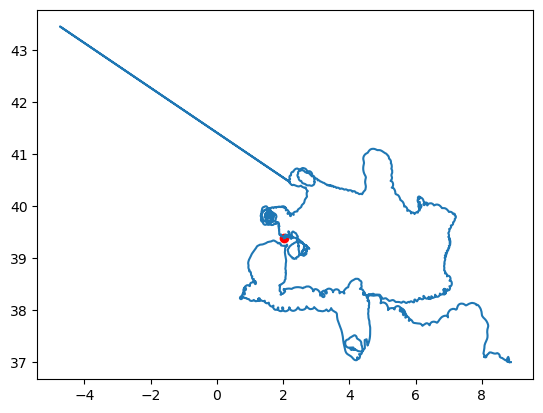

In [12]:
plt.plot(ds00.LON, ds00.LAT)
plt.scatter(ds00.LON[0], ds00.LAT[0], c='r')

# 2. Processing:

In [13]:
# Checking time interval:

print(ds00.time[0].data)
print(ds00.time[1].data)

# --> Should be: 
# 10 mins freq. for CARTHE
# 5 mins HEREON
# 1h SVP-B

2023-02-23T18:00:00.000000000
2023-02-23T19:00:00.000000000


## 2.1. Identifying large time gaps (to kill drifter traj trash)

In [14]:
diff_time_thres = 3600*3 # [s]

In [15]:
dt_drif = ds00.time.diff("time").dt.seconds #ds00c

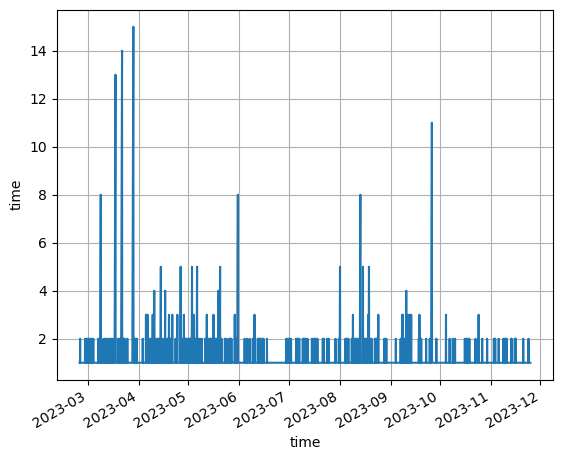

In [16]:
# Plotting diff in hours:
# ((ds00.time.diff("time") / 1.e9) / 3600.).plot()
(ds00.time.diff("time")/ np.timedelta64(1, 'h') ).plot()
plt.grid()


### Subselecting between 14 h time diff and 11h gaps:

In [18]:
# # just using np.where, find cleaner method with array to find indices:
# inds_trash = np.where(dt_drif > diff_time_thres)[0]
# print(inds_trash)
# print(inds_trash.size)

[ 292  487  567  713 1000 1087 1146 1352 1501 1565 1856 1877 2118 3567
 3846 3880 3958 4481 4832]
19


In [19]:
# if inds_trash.size > 0: 
#     ds01 = ds00.where(ds00.time<ds00.time[inds_trash[0]+2], drop=True) # to improve 
#     # + 2 because +1 of normal python indices , and 1 more because based on the indices of the array of time differences
# elif inds_trash.size == 0:
#     ds01 = ds00.copy()
# else:
#     print('Problem')
#     fsdgsdfg

In [18]:
inds_dt01 = 15. * 60 * 60 # [s]

inds_trash_p1 = np.where(dt_drif >= inds_dt01)[0]
print(inds_trash_p1)
print(inds_trash_p1.size)



[713]
1


In [19]:
inds_dt02 = 11. * 60 * 60 # [s]
inds_trash_p2 = np.where(dt_drif == inds_dt02)[0]
print(inds_trash_p2)
print(inds_trash_p2.size)

[4832]
1


In [24]:
ds01 = ds00.where((ds00.time>ds00.time[inds_trash_p1[0]+2]) & (ds00.time<ds00.time[inds_trash_p2[0]-2]), drop=True) # to improve 

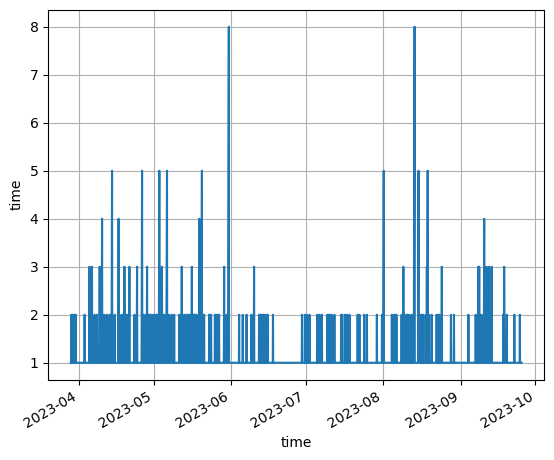

In [26]:
# Plotting diff in hours:
(ds01.time.diff("time")/ np.timedelta64(1, 'h') ).plot()
plt.grid()


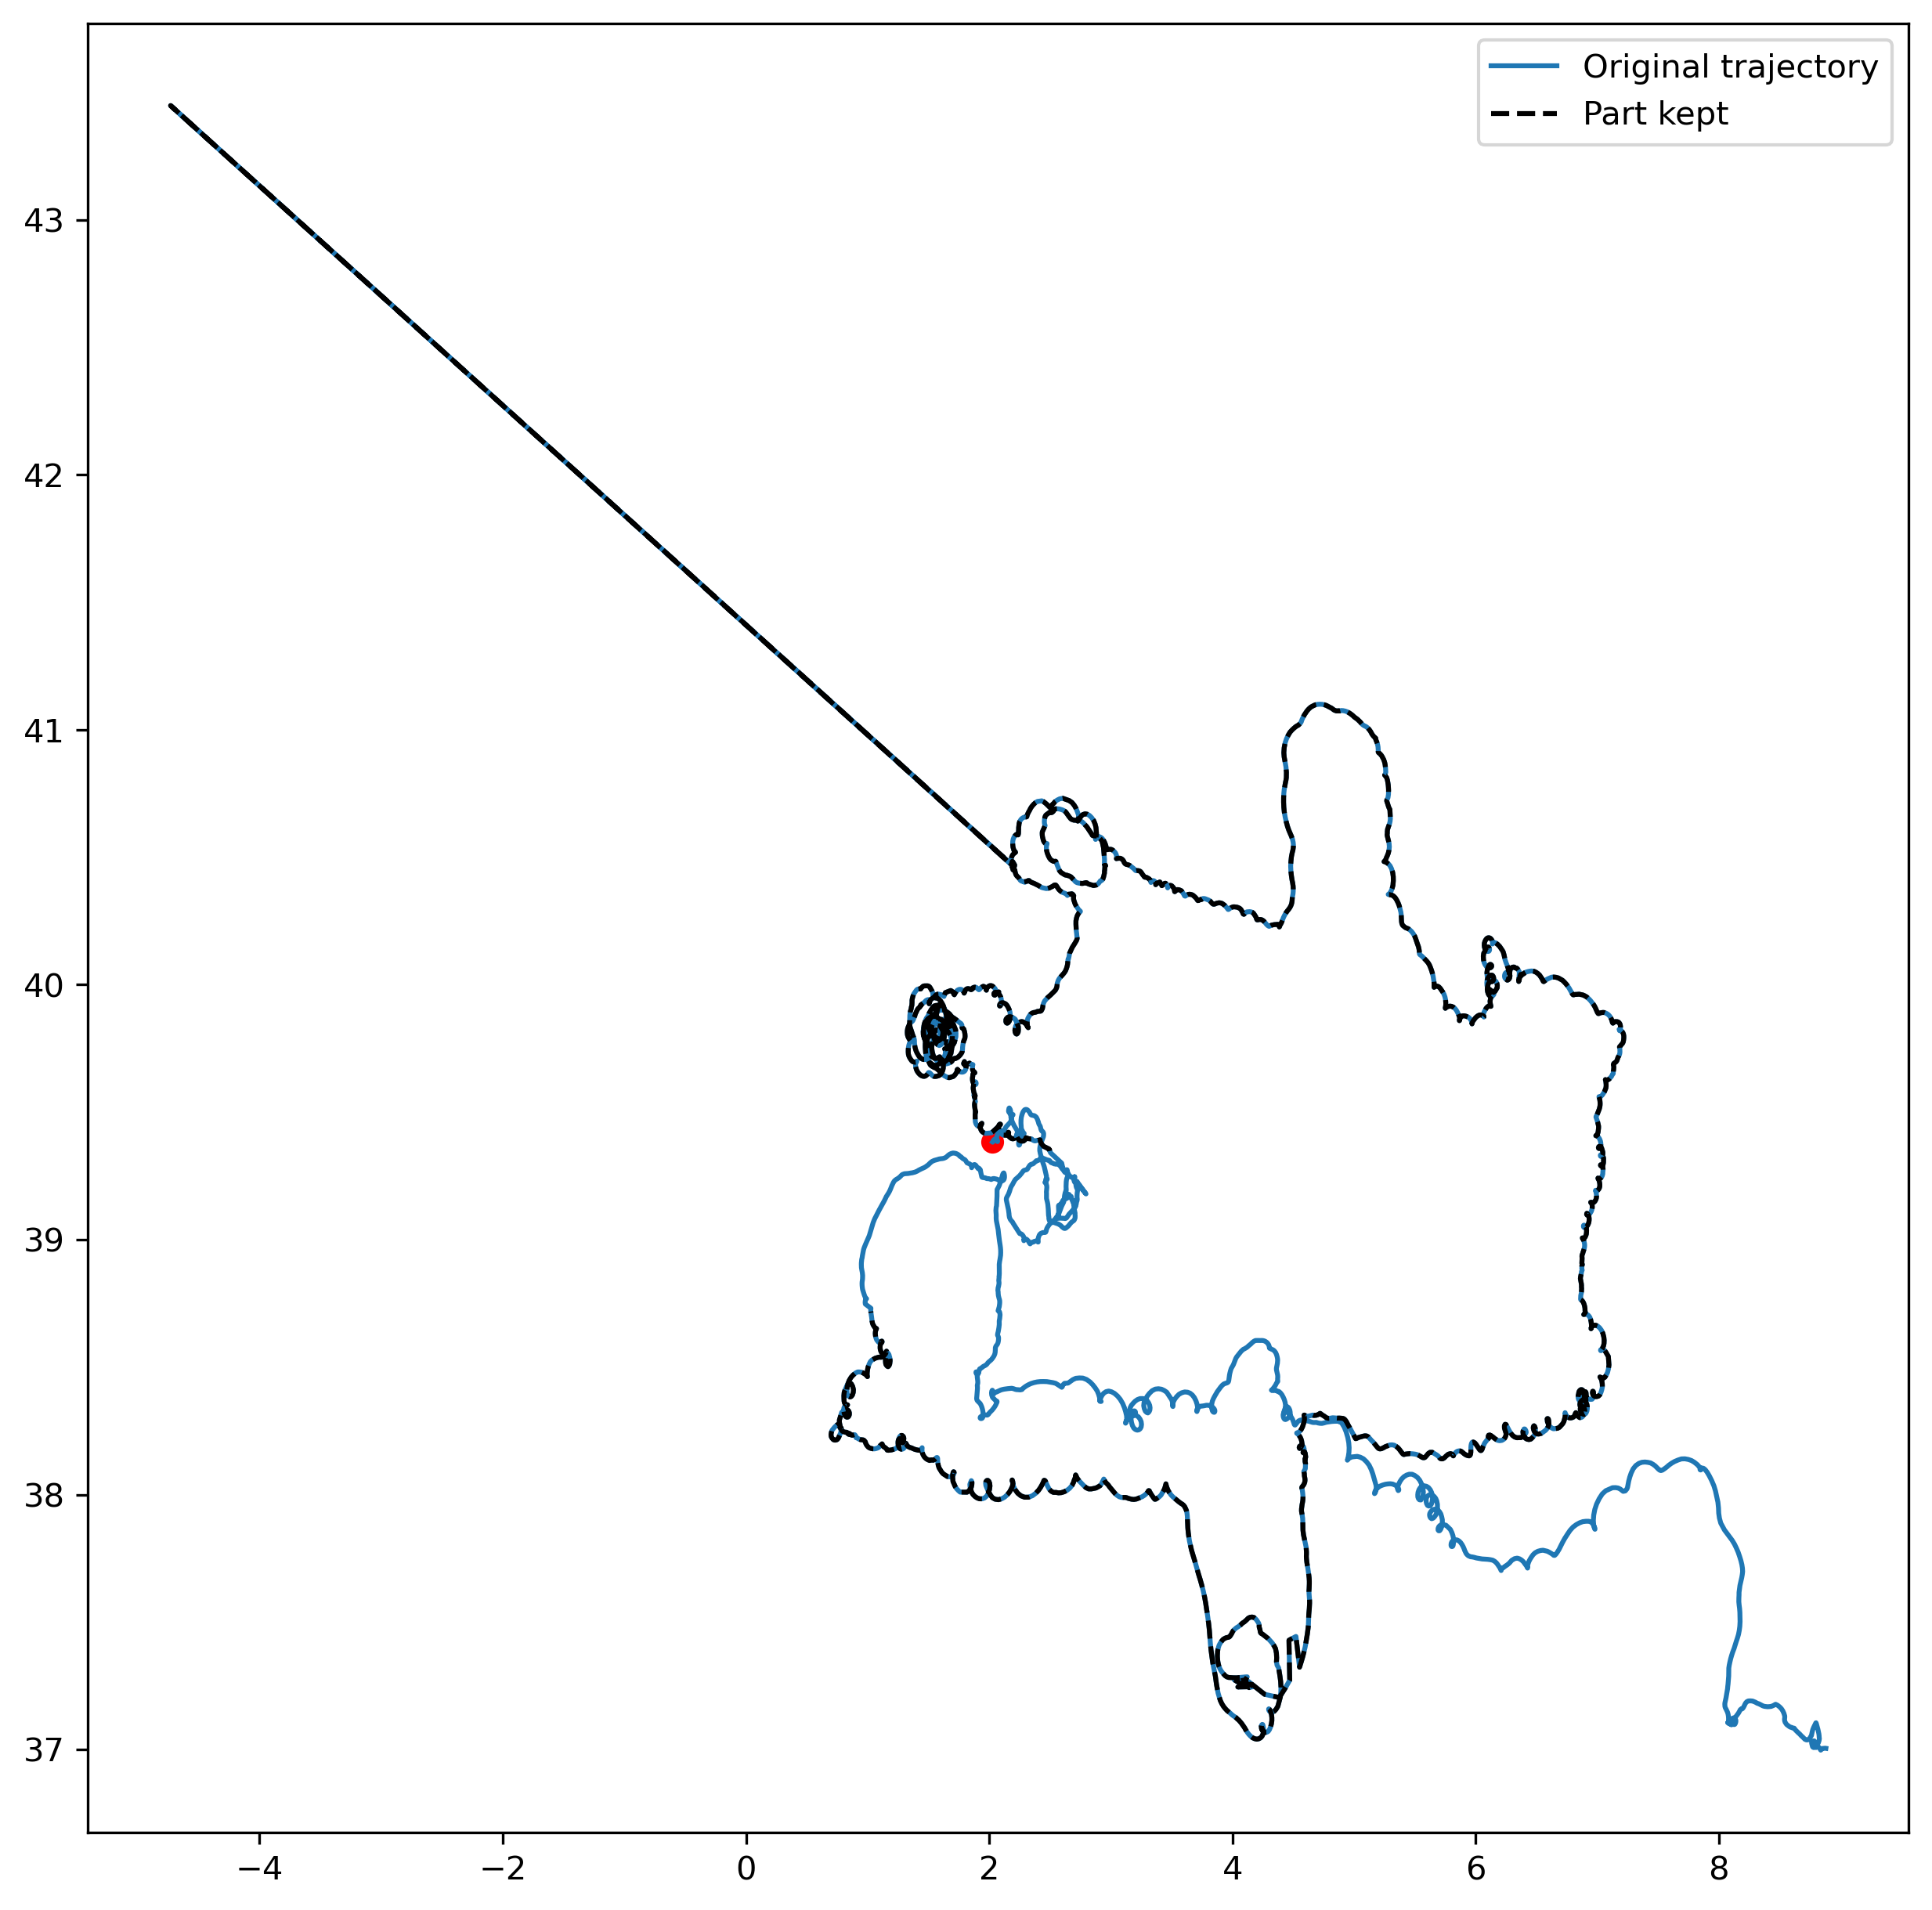

In [28]:
# if inds_trash.size > 0: 
#     plt.figure(figsize=(14,10), dpi=300)
#     plt.plot(ds00.LON, ds00.LAT, label='Original trajectory')
#     plt.scatter(ds00.LON[0], ds00.LAT[0], c='r')
#     plt.plot(ds00.LON[inds_trash[0]::], ds00.LAT[inds_trash[0]::], '--k', label='Part to be removed')
#     plt.legend()
# else:
#     print(f'Nothing to plot, no gap bigger than {diff_time_thres/3600} hours')

plt.figure(figsize=(10,10), dpi=300)
plt.plot(ds00.LON, ds00.LAT, label='Original trajectory')
plt.scatter(ds00.LON[0], ds00.LAT[0], c='r')
plt.plot(ds01.LON, ds01.LAT, '--k', label='Part kept')
plt.legend()


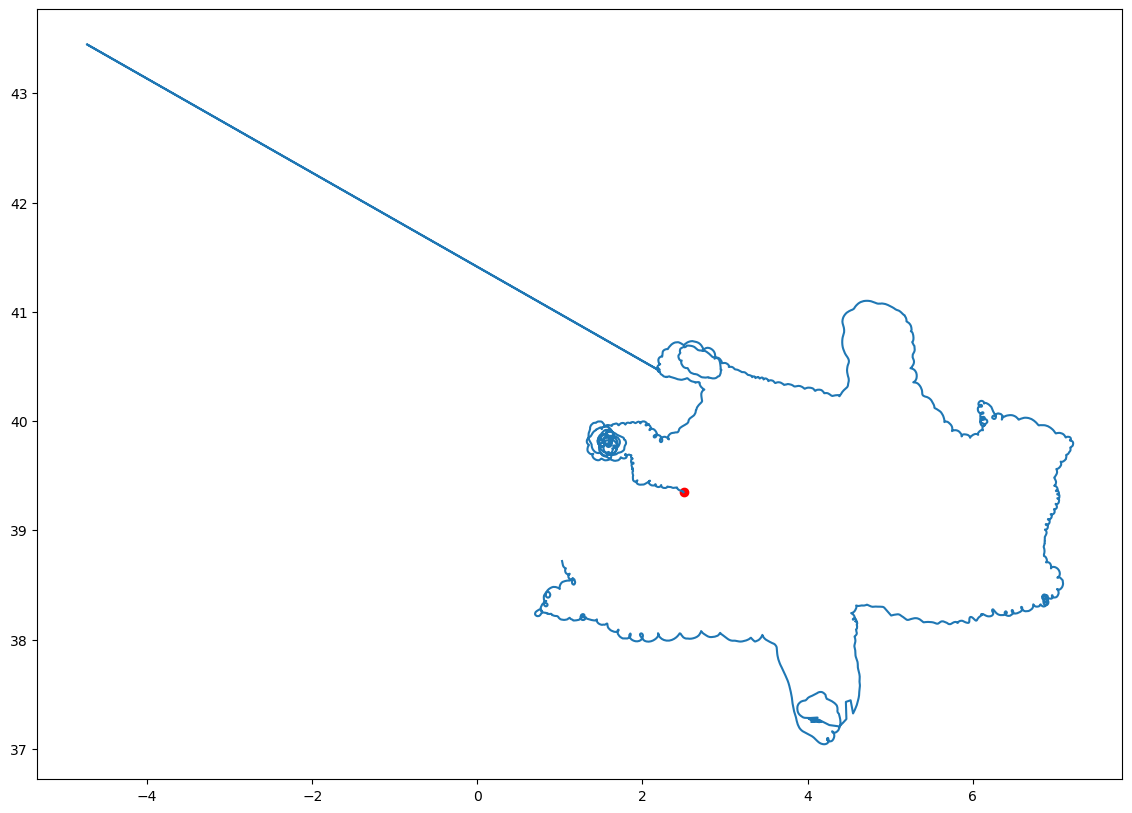

In [29]:
plt.figure(figsize=(14,10))
plt.plot(ds01.LON, ds01.LAT)
plt.scatter(ds01.LON[0], ds01.LAT[0], c='r')

## 2.2. Resampling to regular 10 mins. intervals:
(constant 10 mins and "o'clock" times)

### 2.2.1. Making lon and lat variables instead of coordinates
If we do not do this step when resampling we loose lon and lat in the dataset.  To keep in mind that this may give problems in further calculations with xarray that might need lon and lat as coords.
***  Not needed for the SVP, LON and LAT are already variables

In [39]:
#ds01 = ds01.reset_coords("LON")
#ds01 = ds01.reset_coords("LAT")

### 2.2.2. Drop string variables

In [30]:
ds01

<xarray.Dataset>
Dimensions:        (time: 4114)
Coordinates:
  * time           (time) datetime64[ns] 2023-03-28T14:00:00 ... 2023-09-25T1...
Data variables:
    platform_code  (time) object '6102812' '6102812' ... '6102812' '6102812'
    country        (time) object 'UNKNOWN' 'UNKNOWN' ... 'SPAIN' 'SPAIN'
    LAT            (time) float64 39.35 39.35 39.35 39.36 ... 38.71 38.71 38.72
    LON            (time) float64 2.498 2.497 2.49 2.492 ... 1.03 1.028 1.026
    sst            (time) float64 16.7 16.68 16.55 16.48 ... 25.66 25.74 25.81
    slp            (time) float64 1.027e+03 1.026e+03 ... 1.021e+03 1.021e+03

In [31]:
# To apply interpolate, we need to remove the trajectory variable because it is a string not a float (number)
ds01 = ds01.drop_vars("platform_code")
ds01 = ds01.drop_vars("country") 

#ds01 = ds01.drop_vars("DEPTH") # trajectory variable unnecessary, check with Lara --> not better attrubte?

### 2.2.3. Resampling:

In [32]:
f"{int(temp_res)}s"

'3600s'

In [33]:
ds02 = ds01.resample(time="1H").interpolate("linear") # xarray resample works very differently from pandas


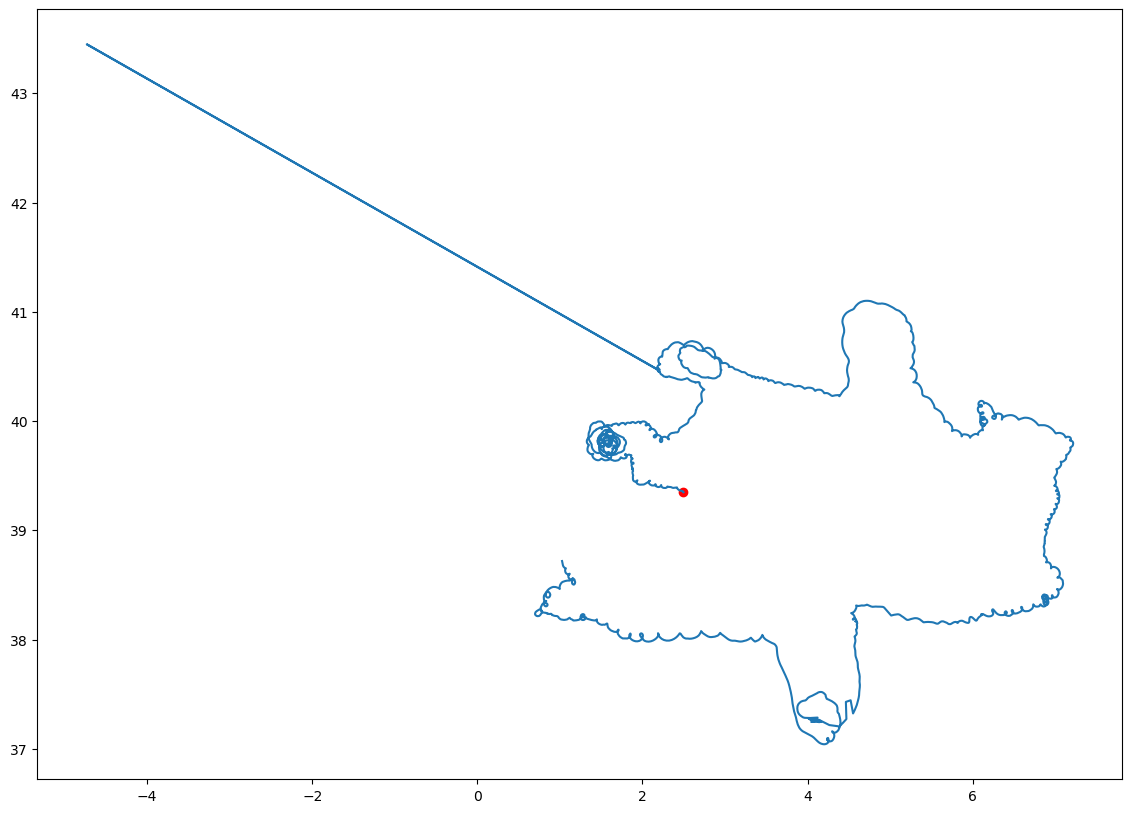

In [34]:
plt.figure(figsize=(14,10))
plt.plot(ds02.LON, ds02.LAT)
# plt.scatter(ds02.LON[0], ds02.LAT[0], c='r') # first point is nan now
plt.scatter(ds02.LON[1], ds02.LAT[1], c='r')

# --> spikes now smaller but still present
# To improve: maybe better to remove spikes with lon and lat (thres 0.02?) before resampling so that spike not spread

## 2.3. Calculate forward and backward velocities

In [35]:
ds02

<xarray.Dataset>
Dimensions:  (time: 4342)
Coordinates:
  * time     (time) datetime64[ns] 2023-03-28T14:00:00 ... 2023-09-25T11:00:00
Data variables:
    LAT      (time) float64 39.35 39.35 39.35 39.36 ... 38.7 38.71 38.71 38.72
    LON      (time) float64 2.498 2.497 2.49 2.492 ... 1.031 1.03 1.028 1.026
    sst      (time) float64 16.7 16.68 16.55 16.48 ... 25.62 25.66 25.74 25.81
    slp      (time) float64 1.027e+03 1.026e+03 ... 1.021e+03 1.021e+03

In [36]:
# Calculate forward and backward finite differences
speed, ufor, vfor = latlon2uv_dir(ds02.LAT, ds02.LON, temp_res, 'forward')
_, uback, vback = latlon2uv_dir(ds02.LAT, ds02.LON, temp_res, 'back')

In [37]:
# Calculate central value
u = (ufor + uback) / 2
v = (vfor + vback) / 2


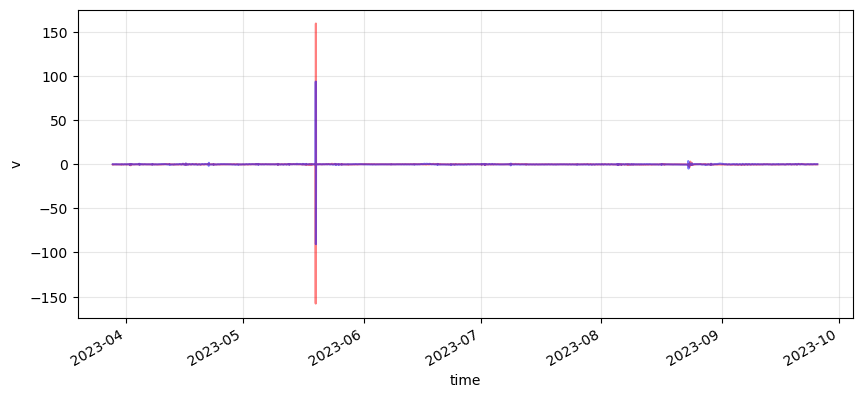

In [38]:
# Check values for spikes
plt.figure(figsize=(10,4))
u.plot(alpha = 0.5, color = "red");
v.plot(alpha = 0.5, color = "blue");
plt.grid(alpha=0.3)

In [39]:
# Add variables to the dataset
ds02 = ds02.assign(U=u)
ds02 = ds02.assign(V=v)
print(list(ds02.keys()))

['LAT', 'LON', 'sst', 'slp', 'U', 'V']


In [40]:
ds02.U.values

array([        nan, -0.15285565,  0.0286595 , ..., -0.0433824 ,
       -0.03855899,         nan])

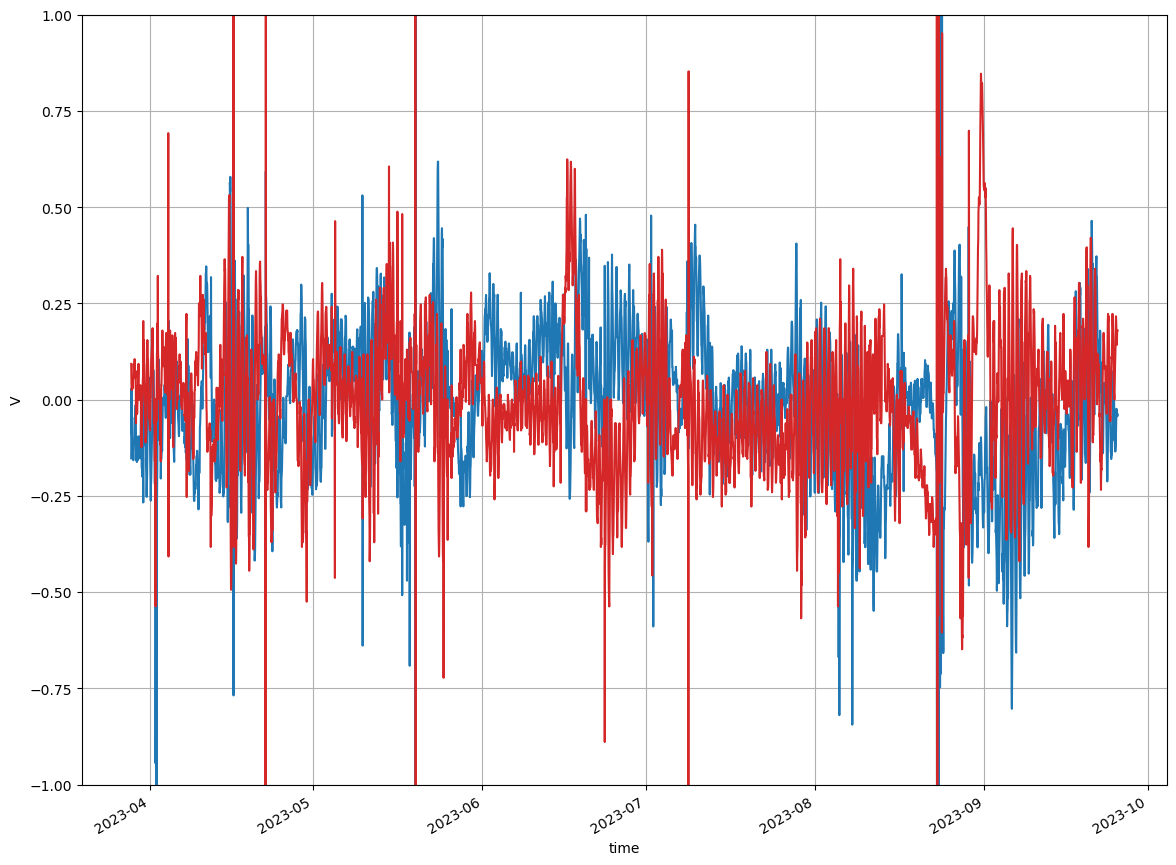

In [41]:
ds02.U.plot(figsize=(14,10))
ds02.V.plot(c='C3')
plt.ylim([-1, 1])
plt.grid()

## 2.4. Spike cleaning:



Cleaning spikes now based on velocity thresholds(absolute velocity (speed))

We will look velocity’s module magnitude to identify spikes due to spurious data







In [42]:
abs_vel = (ds02.U**2 + ds02.V**2)**0.5

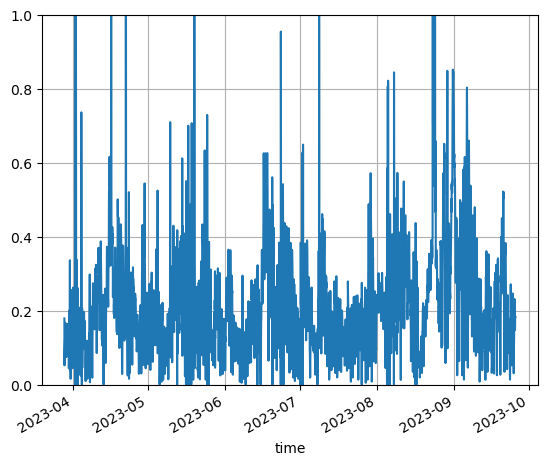

In [43]:
abs_vel.plot()
plt.ylim([0,1])
plt.grid()

### 2.4.1. Large spikes removal

Based on above plot we choose 0.8 m/s.

To improve:
- big spike cleaning with lon and lat thres. before resmpling
- do a moving vel. thres.
- would be better to filter spikes on acceleration, but harder then to choose threshold (less intuitive)

In [44]:
vel_thres = 0.8 # m/s # 1.5 se cuelan spikes # 1. also lowe limits pikes se cuela

In [45]:
ds03 = ds02.where(abs_vel < vel_thres)

In [46]:
abs_vel_thres = (ds03.U**2 + ds03.V**2)**0.5

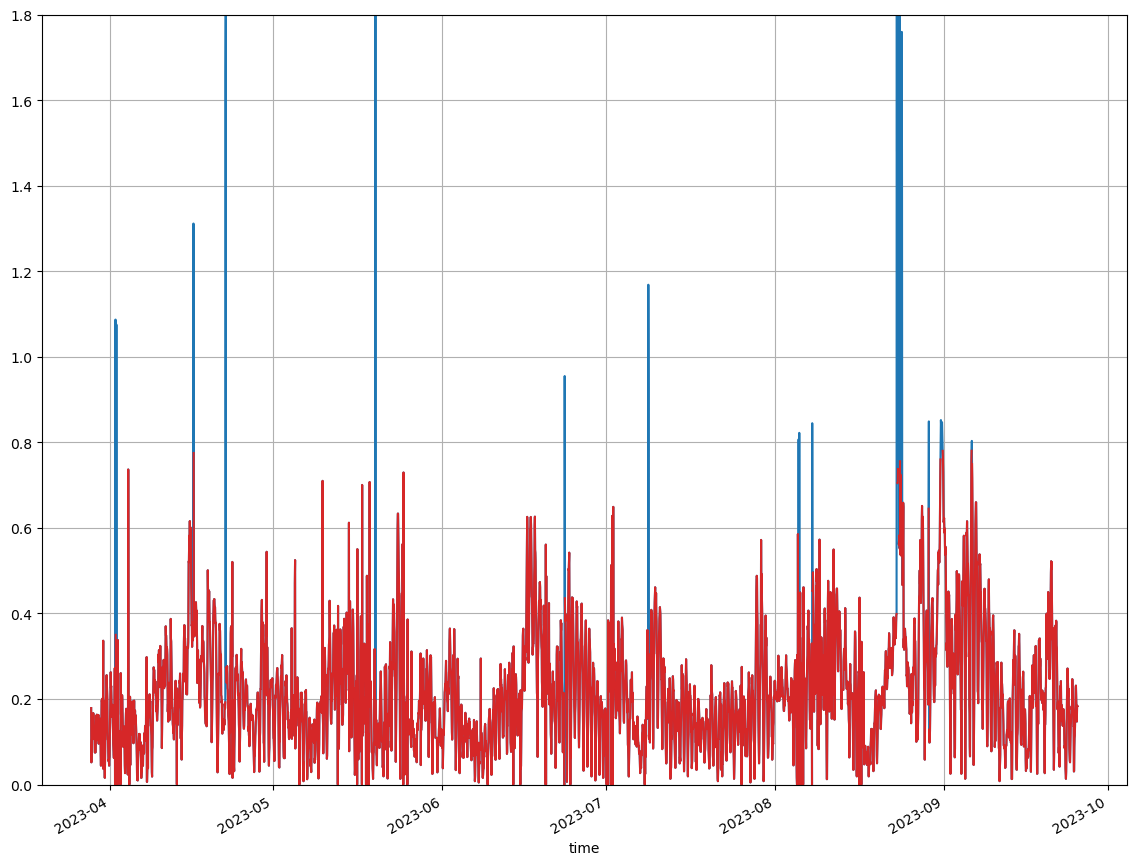

In [47]:
abs_vel.plot(figsize=(14,10))
abs_vel_thres.plot(c='C3')
plt.ylim([0,1.8])
plt.grid()

/opt/anaconda3/envs/venv_fswot/lib/python3.11/site-packages/xarray/plot/utils.py:465: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  _, ax = plt.subplots(figsize=figsize, subplot_kw=subplot_kws)


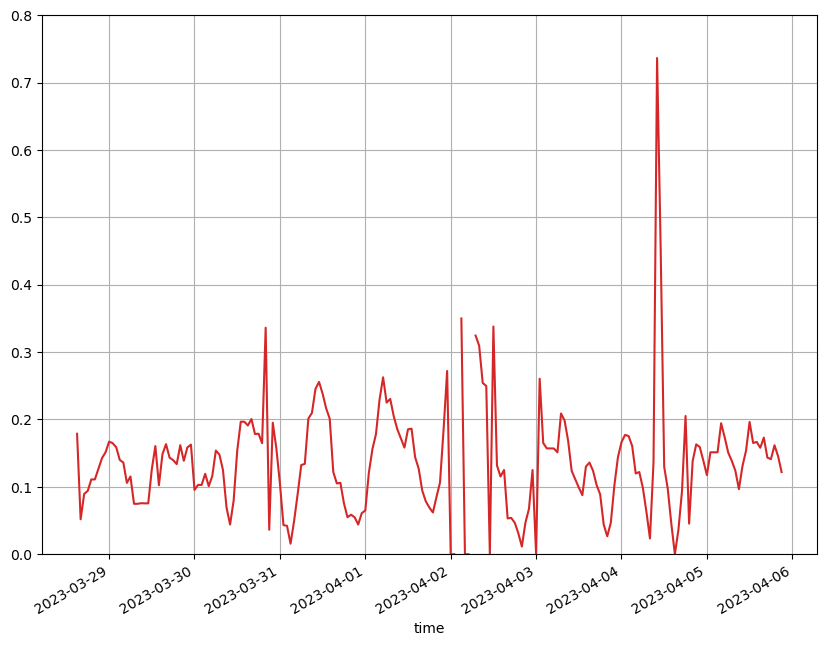

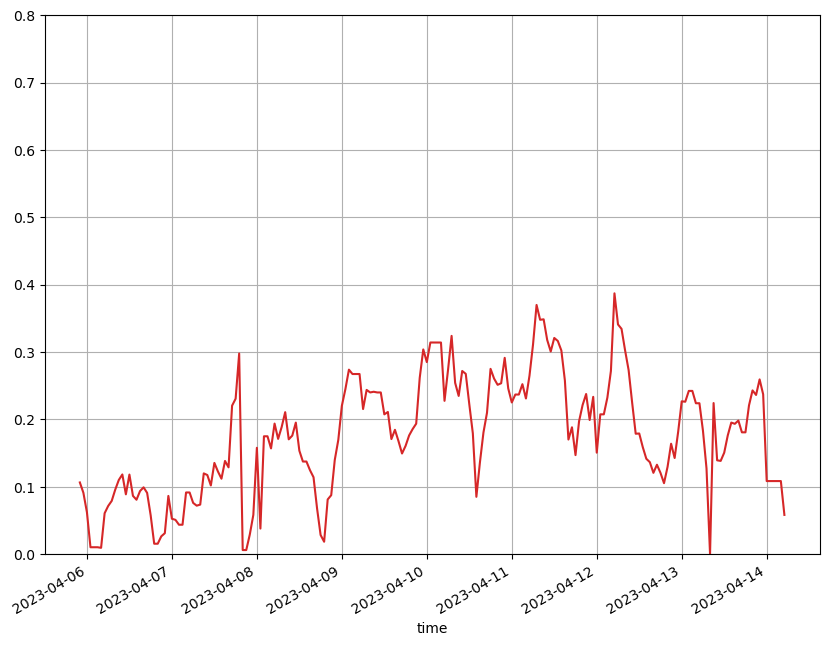

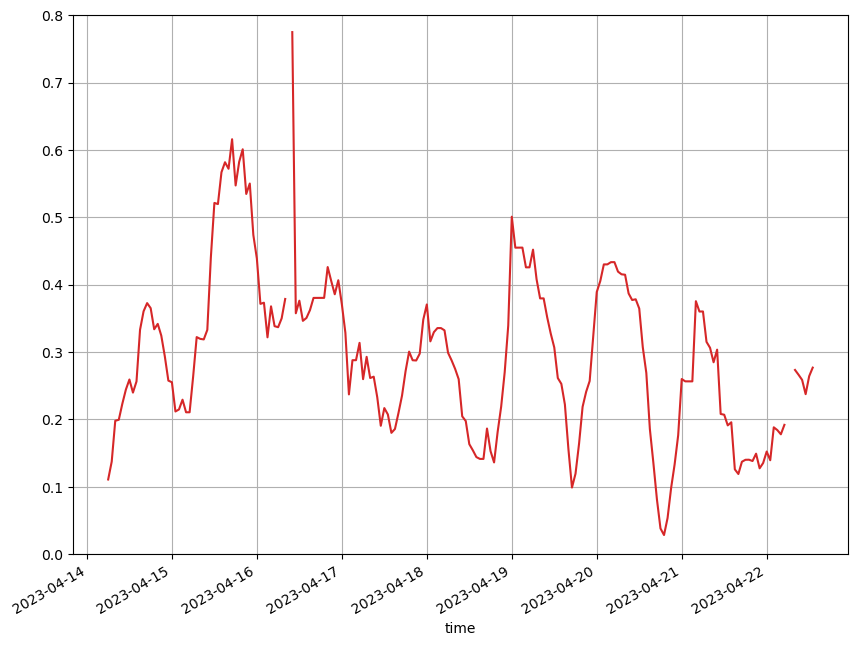

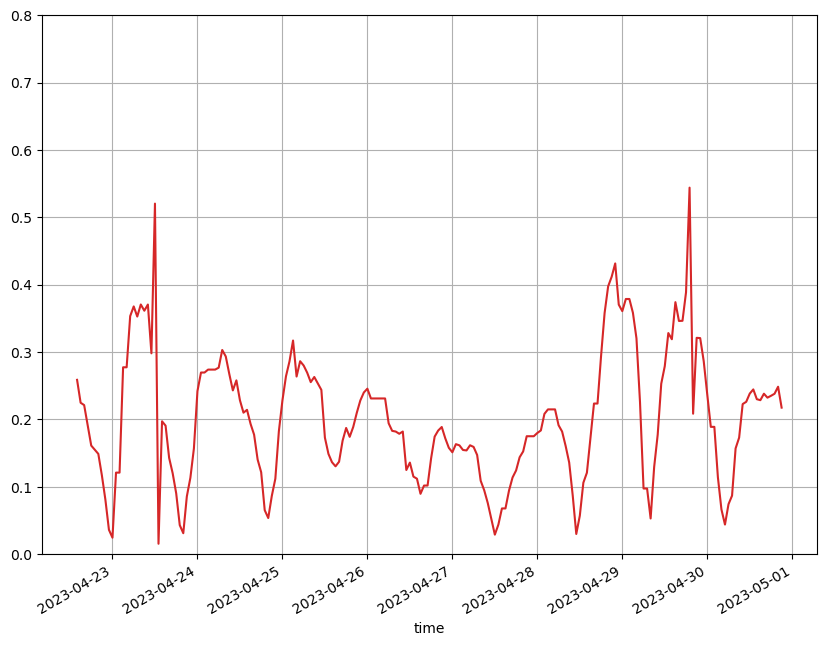

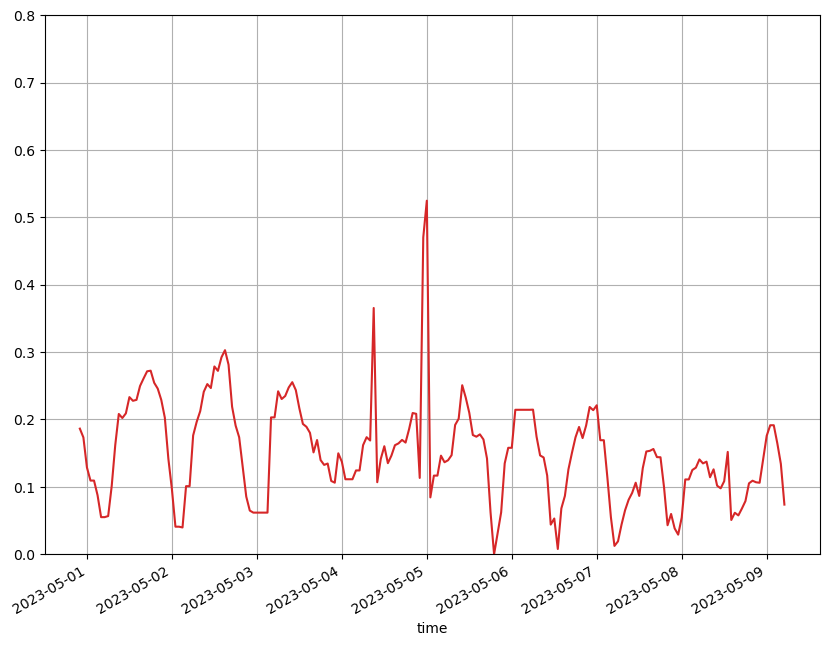

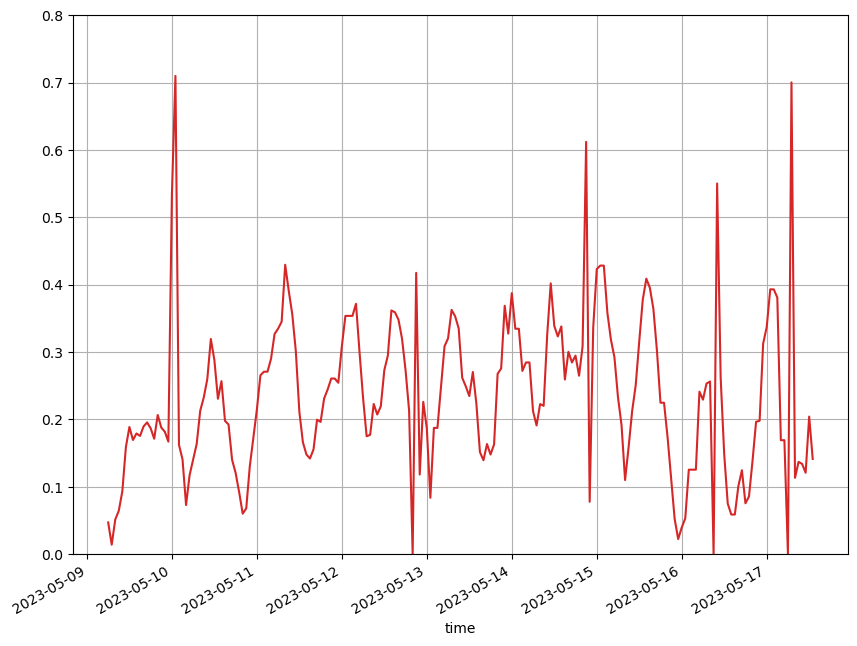

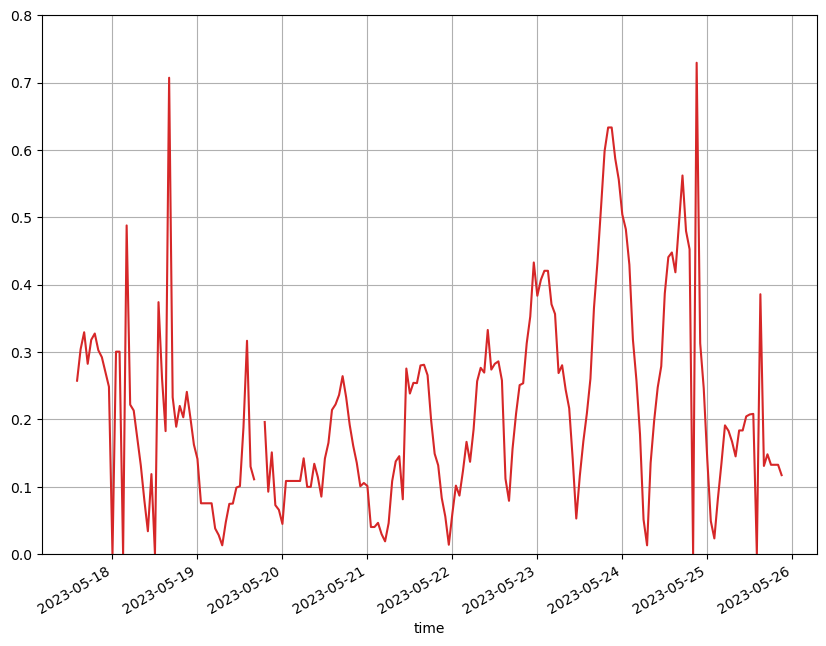

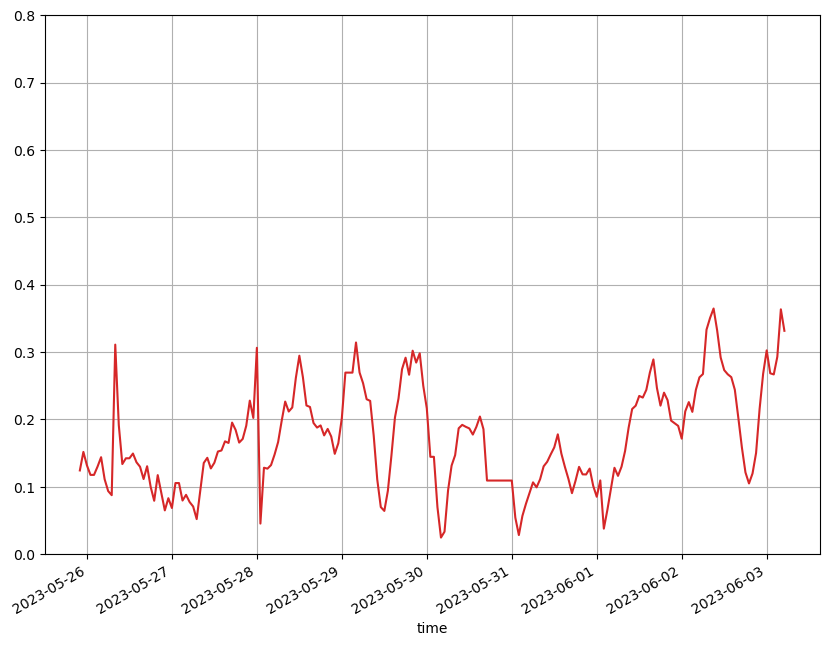

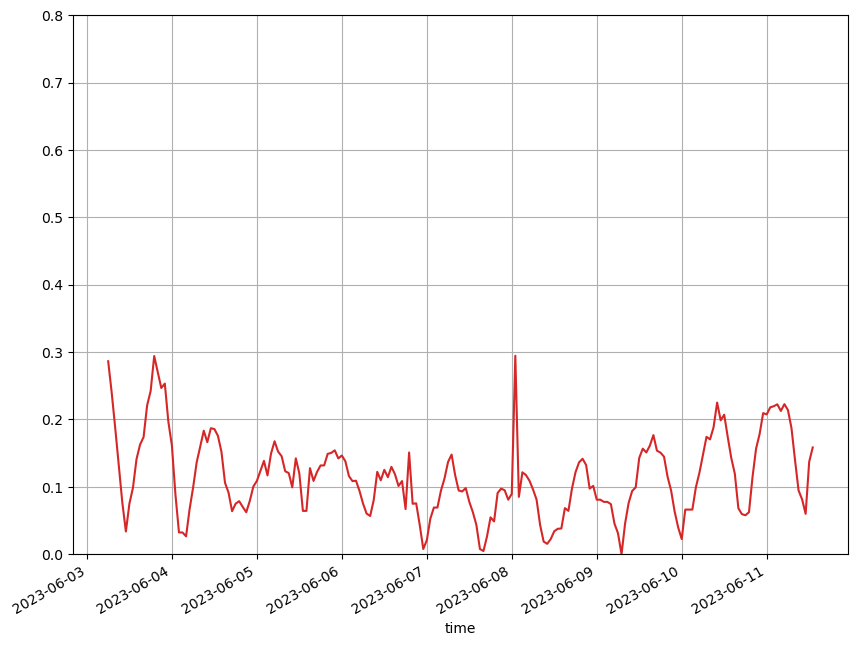

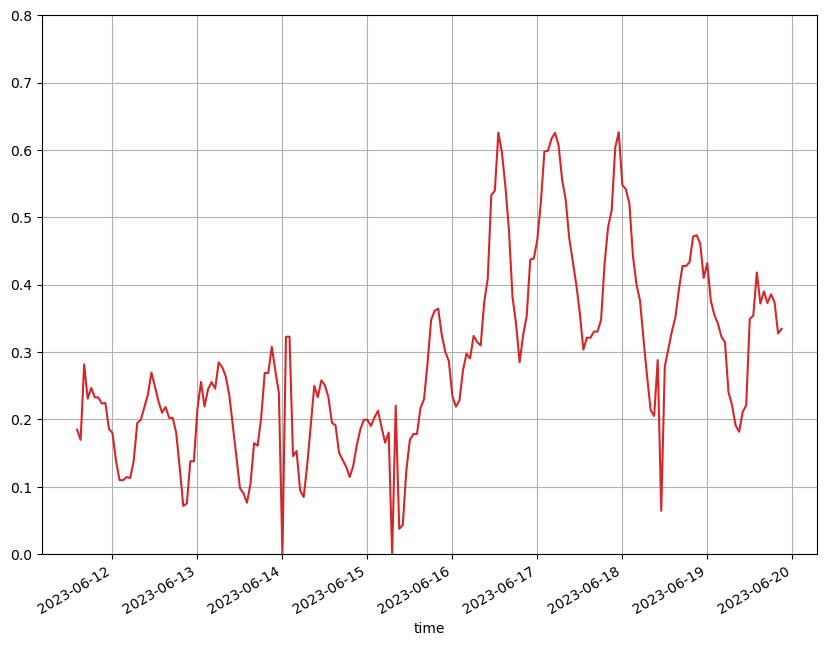

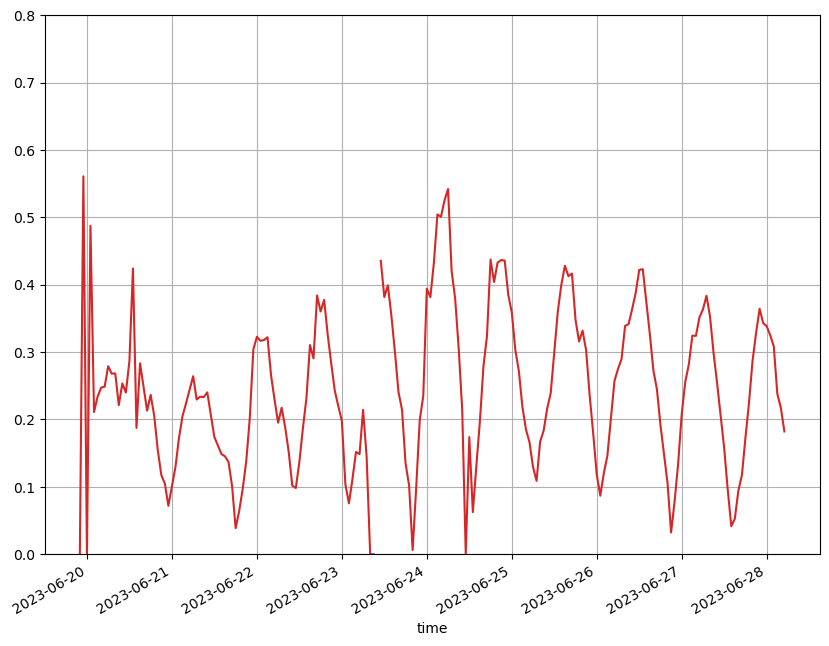

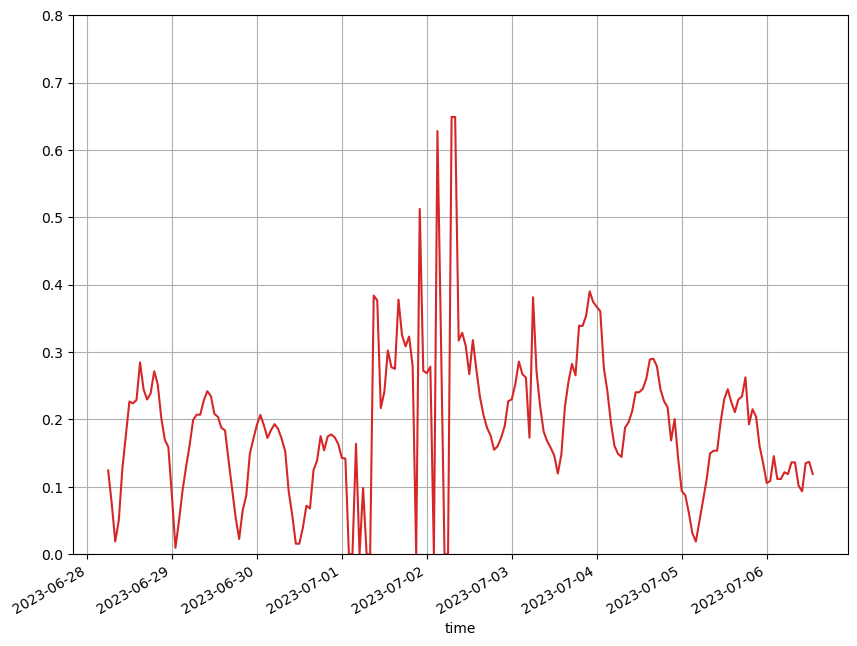

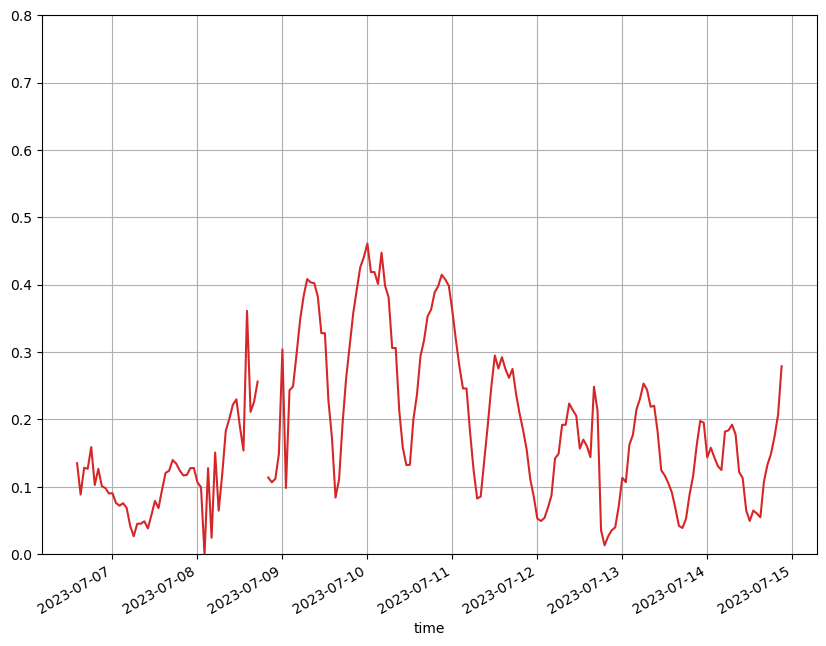

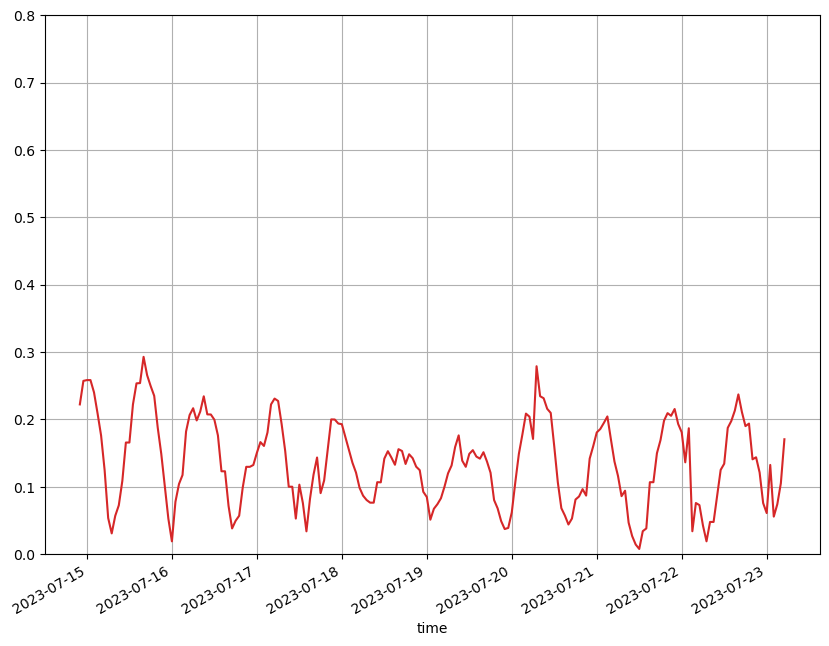

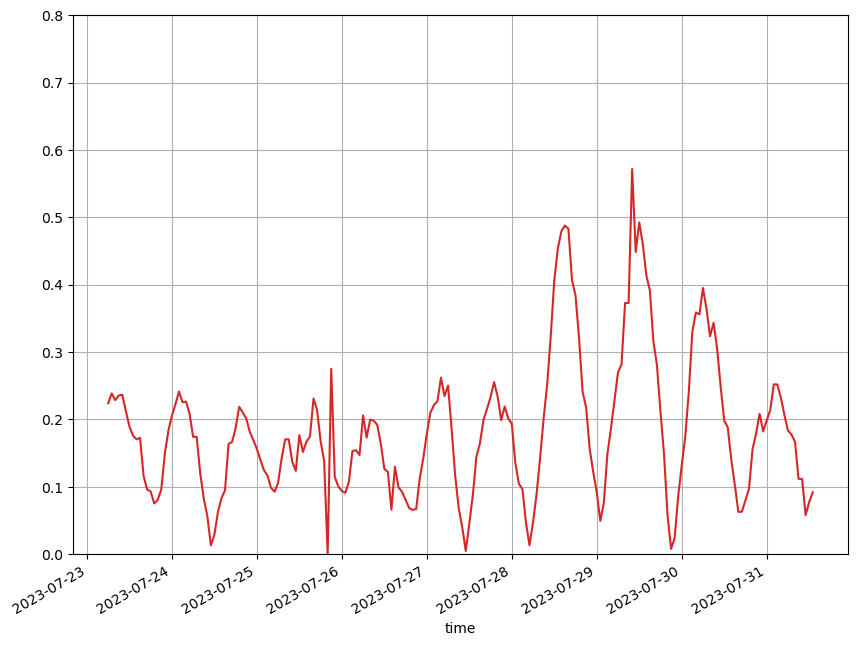

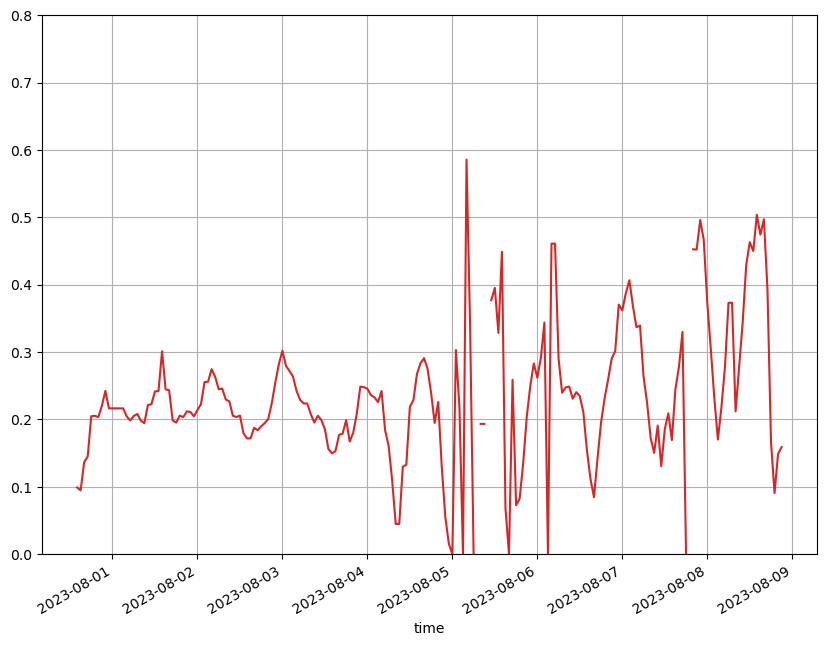

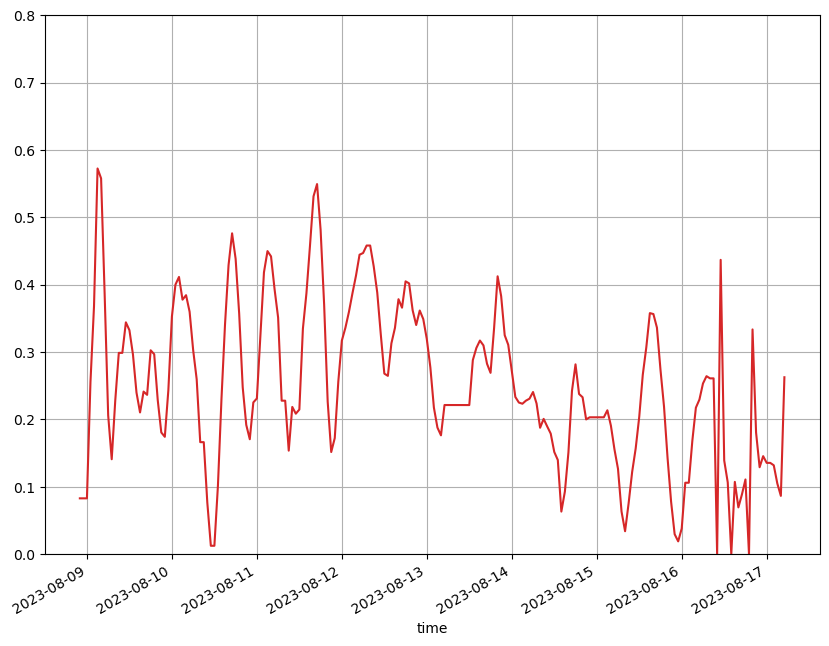

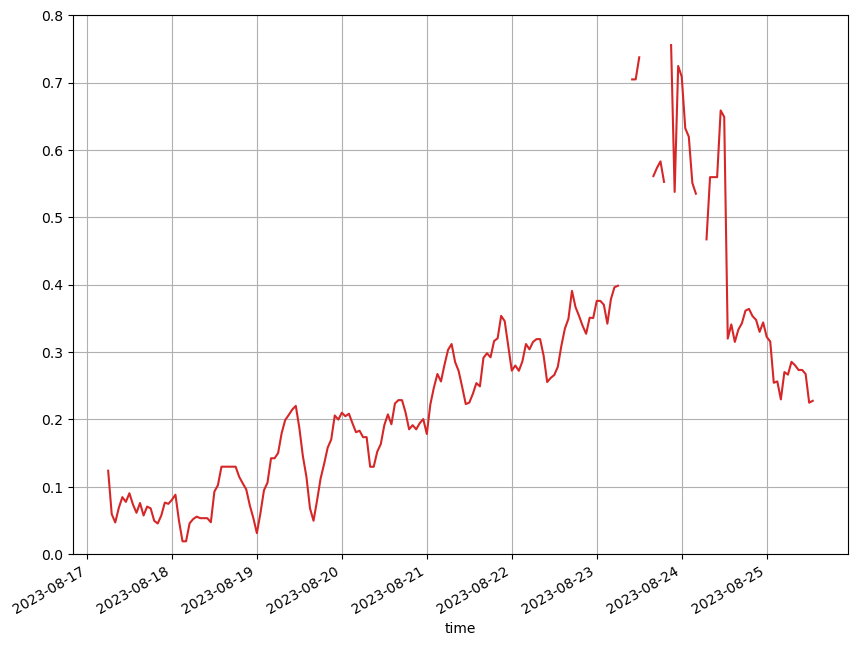

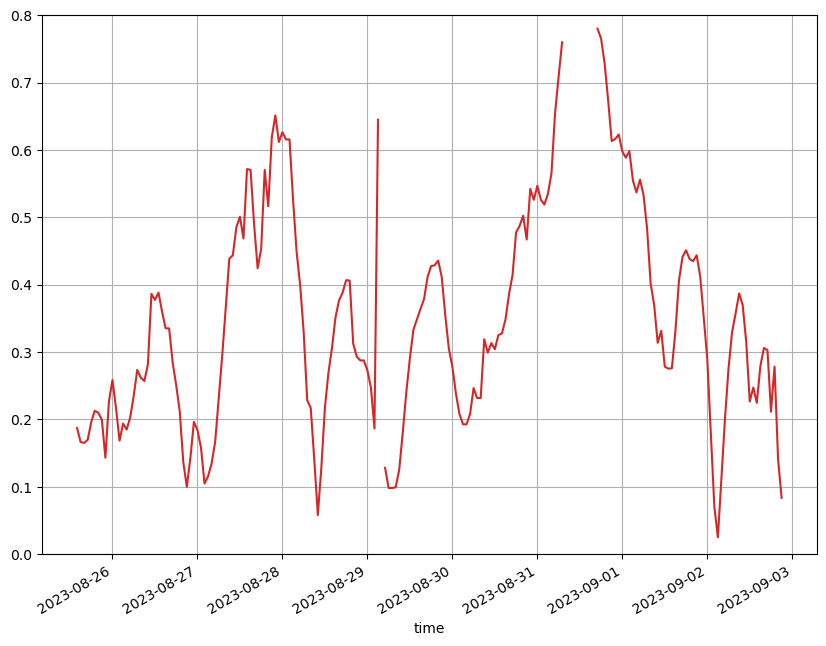

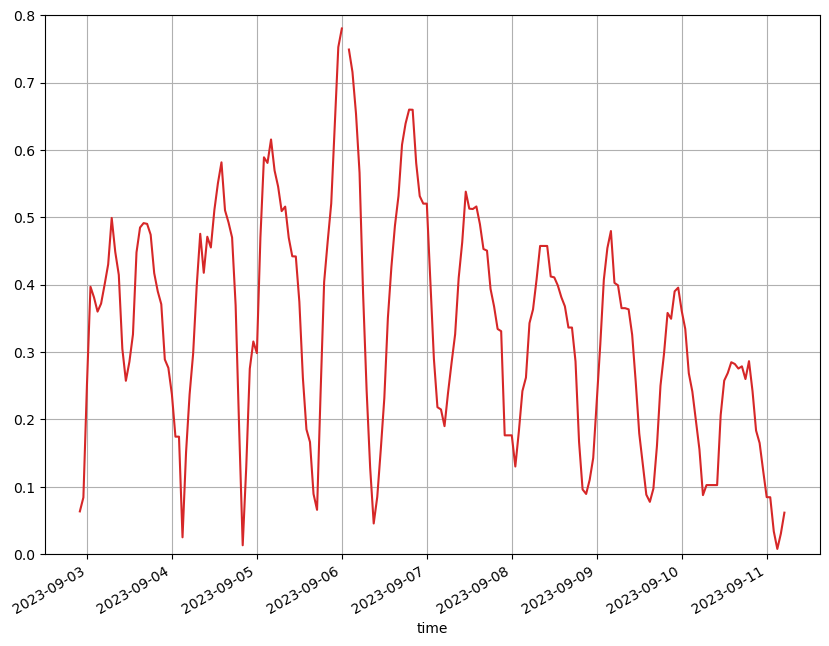

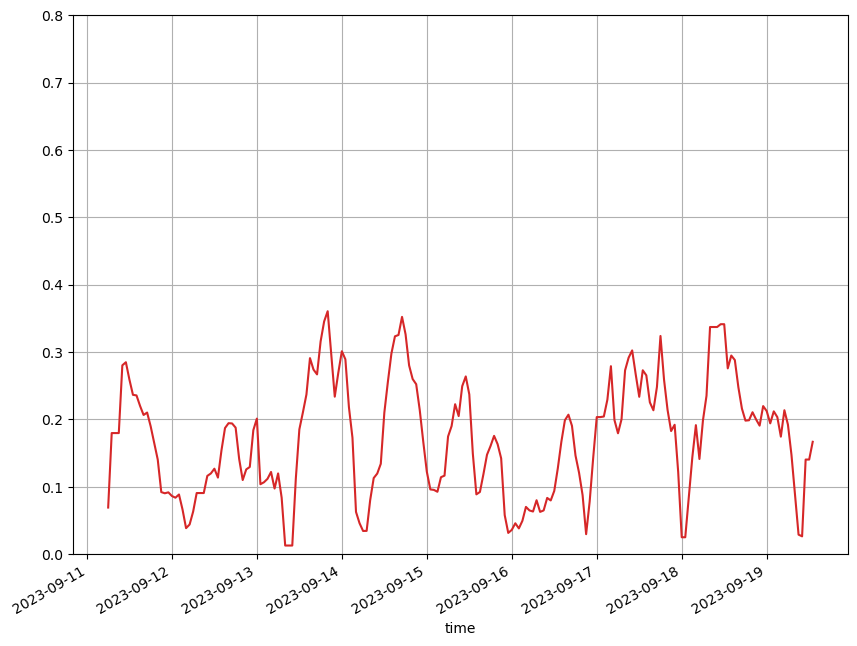

In [48]:
# to visualize data gaps:
for ii in range(0, int(np.floor(len(abs_vel_thres)/200.))):
    abs_vel_thres[(ii*200):((ii+1)*200)].plot(figsize=(10,7), c='C3')
    plt.ylim([0,0.8])
    plt.grid()

### 2.4.2. Smaller spike removal

We will use a moving threshold based on the standard deviation of the window. Values of speed outside this threshold will be marked as spikes

In [49]:
n_window = int(diff_time_thres / temp_res) #12 # we leave like this for now
n_window

3

In [50]:
# Number of points of the window
window_data = n_window

In [51]:
# Obtain the moving std
speed_std = abs_vel_thres.rolling(time=window_data, center=True).std()
speed_median = abs_vel_thres.rolling(time=window_data, center=True).median()
#speed_std = speed_median.rolling(time=int(window_data/2), center=True).std()

In [52]:
# Overview
import matplotlib.dates as mdates
dates = mdates.date2num(ds02['time'])
dates

array([19444.58333333, 19444.625     , 19444.66666667, ...,
       19625.375     , 19625.41666667, 19625.45833333])

In [53]:
speed_median.shape

(4342,)

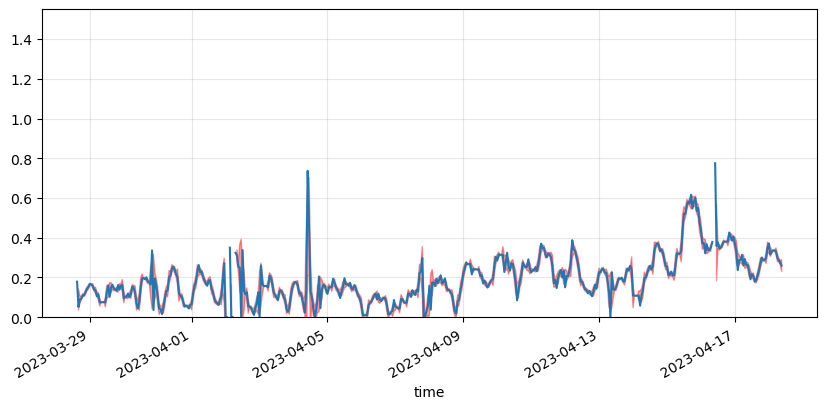

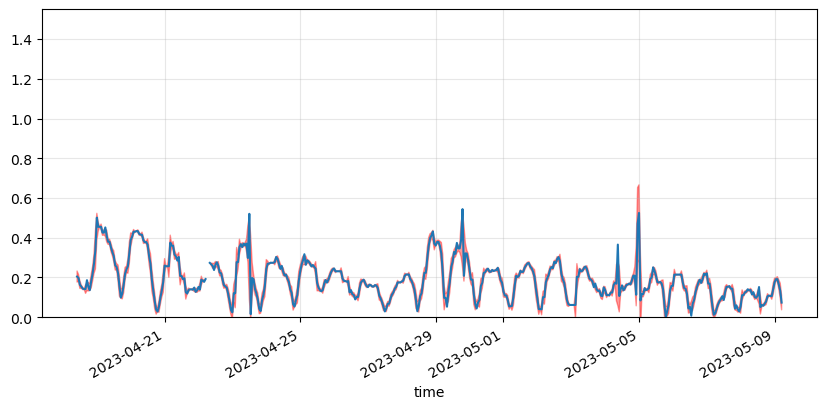

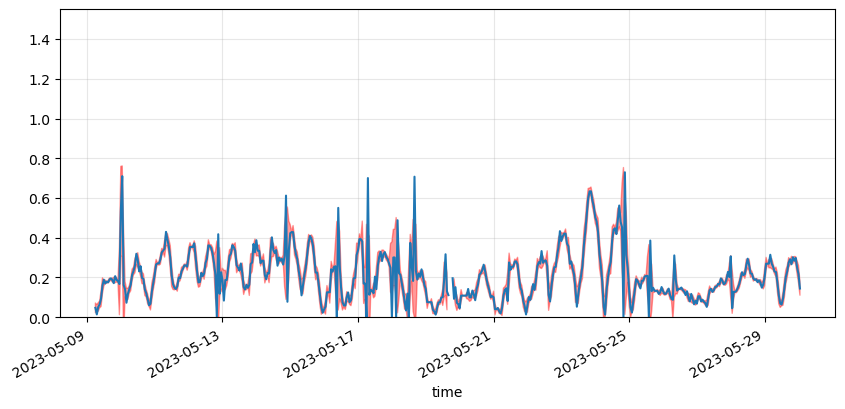

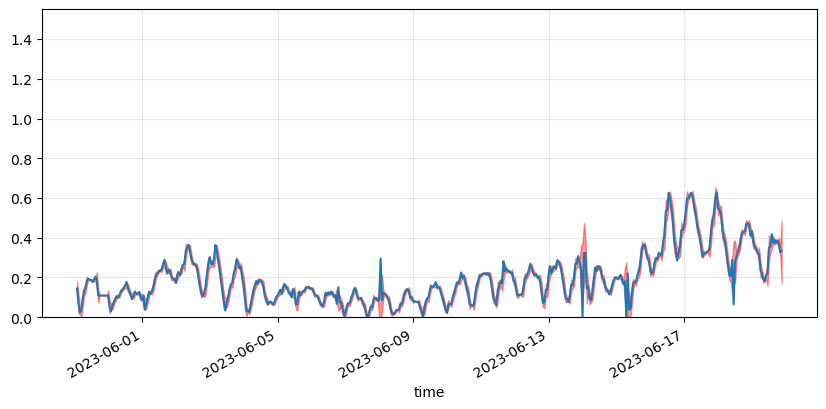

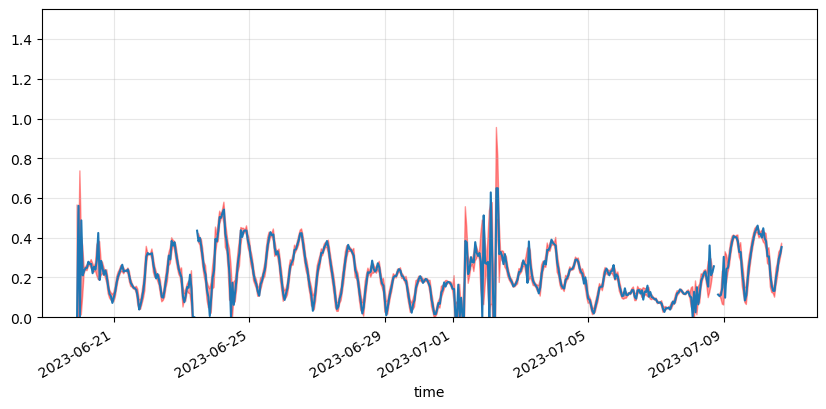

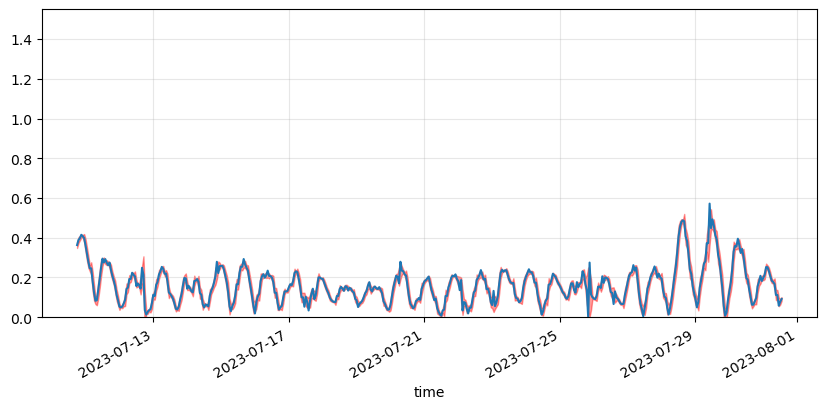

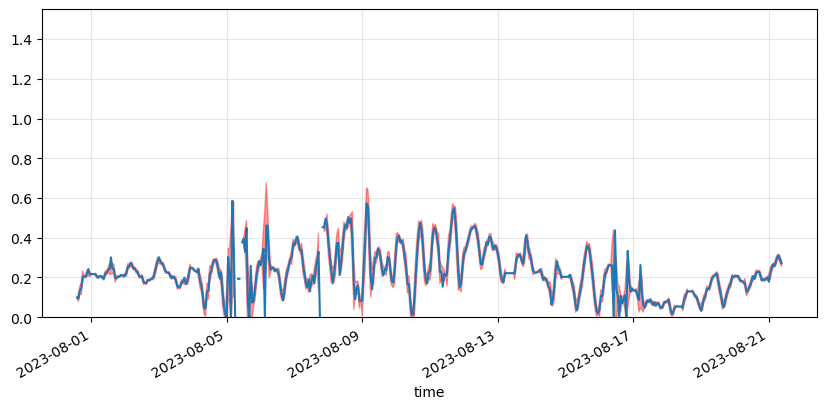

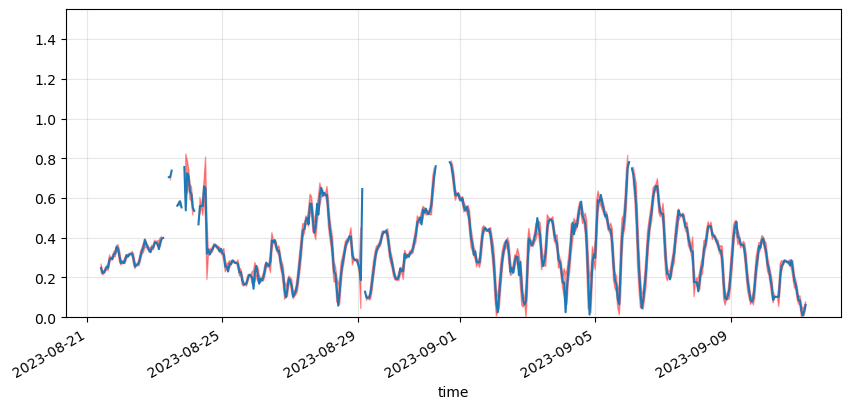

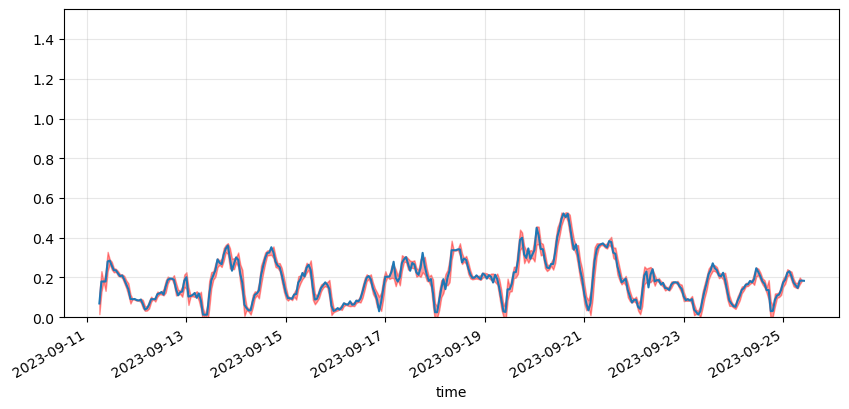

In [54]:
# Zoomed subsamples
tt = 500
for ii in range(0, int(np.ceil(len(abs_vel)/tt))):
    plt.figure(figsize=(10,4))
    x = dates[(ii*tt):((ii+1)*tt)]
    y = speed_median[(ii*tt):((ii+1)*tt)]
    std_zoom = speed_std[(ii*tt):((ii+1)*tt)]
    plt.fill_between(x=x, y1=y-std_zoom, y2=y+std_zoom,color='r',alpha=0.4)
    abs_vel_thres[(ii*tt):((ii+1)*tt)].plot()
    plt.ylim([0,1.55])
    plt.grid(alpha=0.3)

In [55]:
# Set limits for spike cleaning
upper_limit = speed_median + speed_std
bottom_limit = speed_median - speed_std

In [56]:
ds04 = ds03.where((abs_vel_thres < upper_limit) & (abs_vel_thres > bottom_limit))

Zonal component:

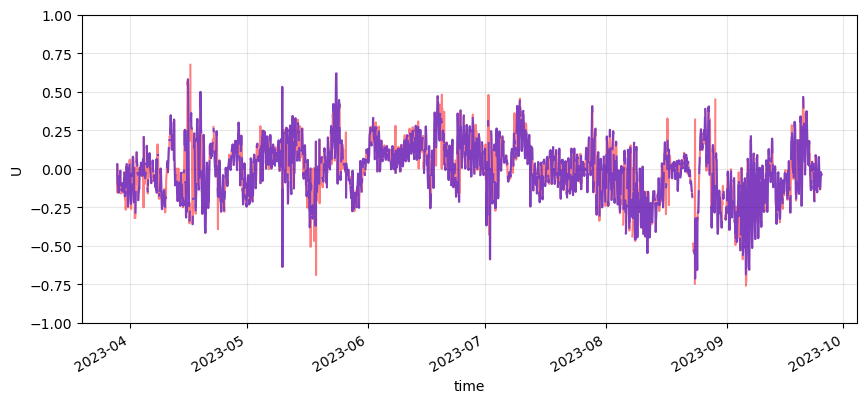

In [57]:
plt.figure(figsize=(10,4))
ds03.U.plot(alpha = 0.5, color = "red", label='old');
ds04.U.plot(alpha = 0.5, color = "blue", label='new');
plt.ylim(-1,1)
plt.grid(alpha=0.3)

Meridional component:

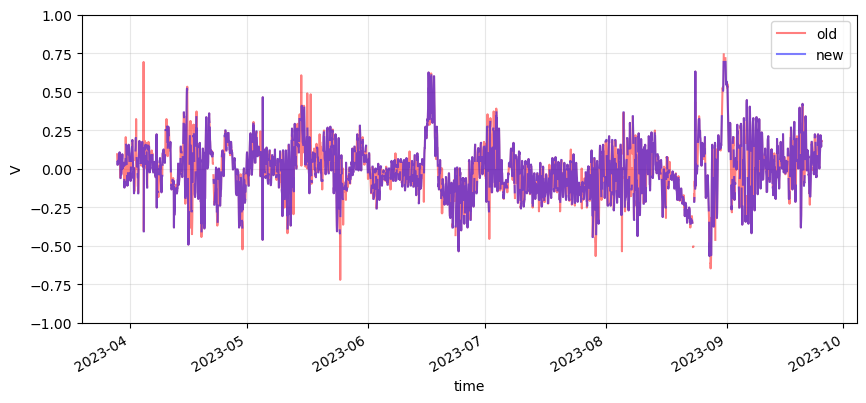

In [58]:
plt.figure(figsize=(10,4))
ds03.V.plot(alpha = 0.5, color = "red", label='old');
ds04.V.plot(alpha = 0.5, color = "blue", label='new');
plt.ylim(-1,1)
plt.grid(alpha=0.3)
plt.legend()

## 2.5. Smoothing

### 2.5.1. Interpolation
(again to fill in spike gaps, smoothing method applied (for now) next does not fill in the gaps) --> to check

In [59]:
# To apply interpolate, we need to remove the trajectory variable because it is a string not a float (number)
#ds05 = ds04.drop_vars("trajectory") # trajectory variable unnecessary, check with Lara --> not better attrubte?

In [60]:
ds05 = ds04.interpolate_na(dim='time', method="pchip") 
# Pchip : cubic with splines interp. (Dani find ref.)

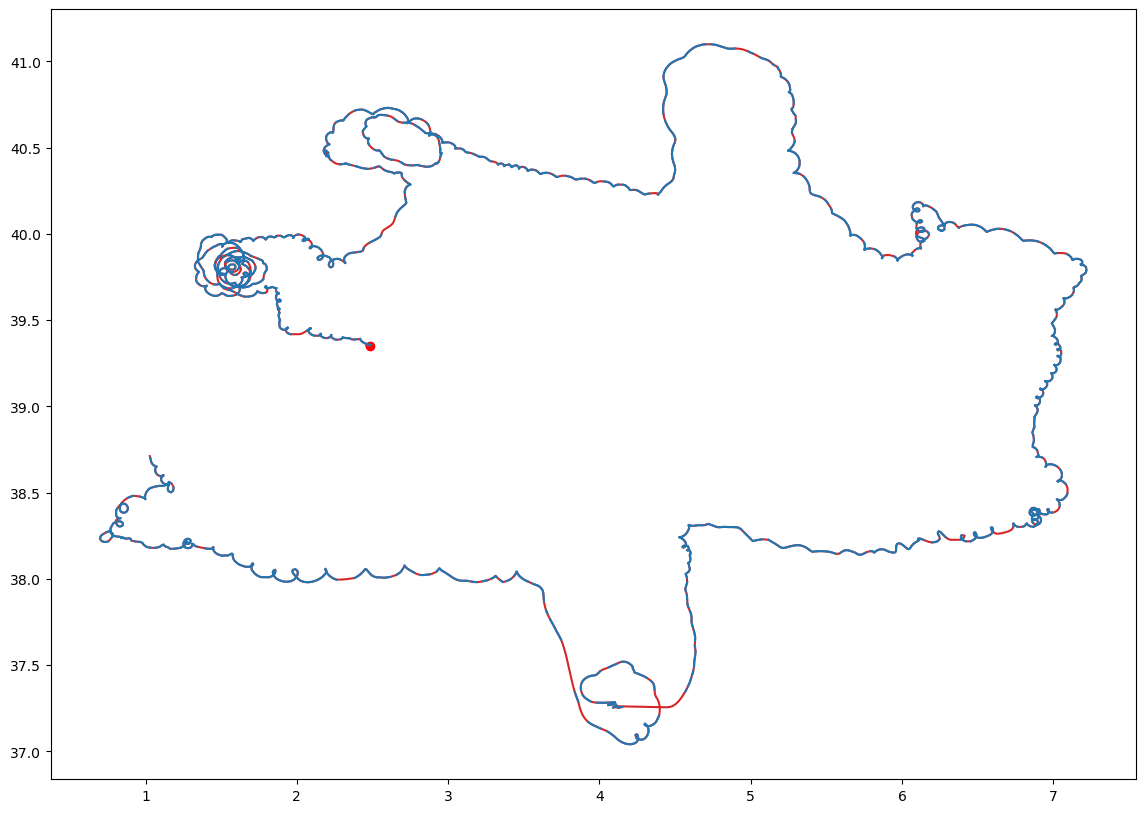

In [61]:
plt.figure(figsize=(14,10))
plt.plot(ds05.LON, ds05.LAT, 'C3')
plt.plot(ds04.LON, ds04.LAT)
plt.scatter(ds05.LON[1], ds05.LAT[1], c='r')

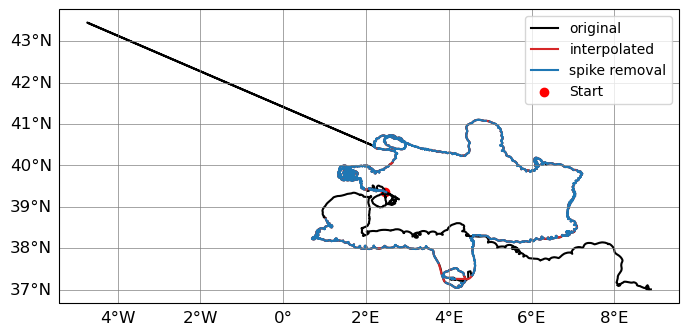

In [62]:
plt.figure(figsize=(8,8))
ax1 = plt.subplot(111, projection=ccrs.PlateCarree())
ax1.plot(ds00.LON, ds00.LAT, 'k', label='original', transform=ccrs.PlateCarree())
ax1.plot(ds05.LON, ds05.LAT, 'C3', label='interpolated', transform=ccrs.PlateCarree())
ax1.plot(ds04.LON, ds04.LAT, label='spike removal', transform=ccrs.PlateCarree())
ax1.scatter(ds05.LON[0], ds05.LAT[0], c='r', label='Start', transform=ccrs.PlateCarree())
plt.legend()

# #############
# # Land
# feature = cartopy.feature.NaturalEarthFeature(name='coastline', category='physical',
#                                               scale='10m', zorder=10,
#                                               edgecolor='black', facecolor='#AAAAAA')
# ax1.add_feature(feature)
#############
# Grid and ticks
gl = ax1.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                  linewidth=0.5, color='gray', linestyle='-') #, alpha=0.5

gl.top_labels = False
gl.right_labels = False

gl.xlabel_style = {'size': 12}#, 'color': 'gray'}
gl.ylabel_style = {'size': 12}#, 'color': 'gray'}
#############

# ax1.plot(ds.LON, ds.LAT, transform=ccrs.PlateCarree(), c='C0', zorder=50) 
# ax1.scatter(ds.LON[-1], ds.LAT[-1], c='C3', edgecolor='k', linewidths=0.8, transform=ccrs.PlateCarree(), label='End', zorder=51) 

# ax1.set_extent(map_extent, crs=ccrs.PlateCarree())
# ax1.legend()
# ax1.set_title('Trajectory of ' + ds.attrs['title'].split(' ')[3].split('-')[-1], size=fsize+2) 

outname = url_drifter.split('/')[-1][0:-1].replace('L0', 'L1').replace('scb', 'ime') #outname
# --> substitute L0 by L1 and scb by ime. [0:-1], because last character in string is ?
outname = outname.split('_')[1]

plt.savefig(savedir_figs + 'traj_parts_' + outname + '.png', dpi=300)

plt.show()


## Zooming in :

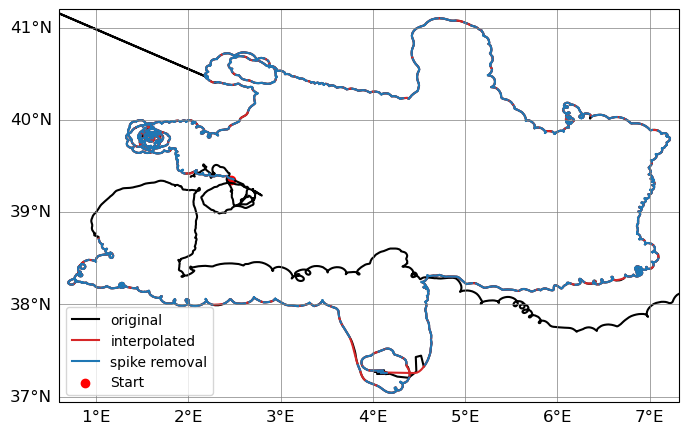

In [63]:
plt.figure(figsize=(8,8))
ax1 = plt.subplot(111, projection=ccrs.PlateCarree())
ax1.plot(ds00.LON, ds00.LAT, 'k', label='original', transform=ccrs.PlateCarree()) # [0:-2900] used for previous plot on LON and LAT wo/ map_extent
ax1.plot(ds05.LON, ds05.LAT, 'C3', label='interpolated', transform=ccrs.PlateCarree())
ax1.plot(ds04.LON, ds04.LAT, label='spike removal', transform=ccrs.PlateCarree())
ax1.scatter(ds05.LON[0], ds05.LAT[0], c='r', label='Start', transform=ccrs.PlateCarree())
plt.legend()

# #############
# # Land
# feature = cartopy.feature.NaturalEarthFeature(name='coastline', category='physical',
#                                               scale='10m', zorder=10,
#                                               edgecolor='black', facecolor='#AAAAAA')
# ax1.add_feature(feature)
#############
# Grid and ticks
gl = ax1.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                  linewidth=0.5, color='gray', linestyle='-') #, alpha=0.5

gl.top_labels = False
gl.right_labels = False

gl.xlabel_style = {'size': 12}#, 'color': 'gray'}
gl.ylabel_style = {'size': 12}#, 'color': 'gray'}
#############

# ax1.plot(ds.LON, ds.LAT, transform=ccrs.PlateCarree(), c='C0', zorder=50) 
# ax1.scatter(ds.LON[-1], ds.LAT[-1], c='C3', edgecolor='k', linewidths=0.8, transform=ccrs.PlateCarree(), label='End', zorder=51) 

thresa = .1
map_extent = [ds04.LON.min().values - thresa, ds04.LON.max().values + thresa
              , ds04.LAT.min().values - thresa, ds04.LAT.max().values + thresa]
ax1.set_extent(map_extent, crs=ccrs.PlateCarree())
# ax1.legend()
# ax1.set_title('Trajectory of ' + ds.attrs['title'].split(' ')[3].split('-')[-1], size=fsize+2) 

outname = url_drifter.split('/')[-1][0:-1].replace('L0', 'L1').replace('scb', 'ime') #outname
# --> substitute L0 by L1 and scb by ime. [0:-1], because last character in string is ?
outname = outname.split('_')[1]

plt.savefig(savedir_figs + 'traj_parts_zoom' + outname + '.png', dpi=300)

plt.show()


### 2.5.2. Applying smoothing
To remove small scale noise and any remaining spikes.

(we apply window to smooth the data on the lon and lat drifters, to the recalculate vels (could also apply directly on vels... we will see later) )


# --> for now we leave it at n=12 <-> 2h (method to be refined as smoothes too much at peaks, very flat)

https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.convolve.html

In [64]:
ds06 = ds05.copy()

Creating new variables with mirror boundary conditions 

(for testing on this see : http://localhost:8889/notebooks/code/drifters/processing/fast_swot_drifter_processing_rough02.ipynb)

In [65]:
nn = 100
lonb = ds05.LON.values
lona = np.flipud(ds05.LON.values[0:nn])
lonc = np.flipud(ds05.LON.values[-nn::])

latb = ds05.LAT.values
lata = np.flipud(ds05.LAT.values[0:nn])
latc = np.flipud(ds05.LAT.values[-nn::])

In [66]:
lon_cat = np.concatenate((lona, lonb, lonc))
lat_cat = np.concatenate((lata, latb, latc))

Applying the window smoothing

In [67]:
window = signal.windows.hamming(n_window) # 6 hours (6 points) 


In [68]:
lon_win = signal.convolve(lon_cat, window, mode='same') / np.sum(window)
ds06["LON"][:] = lon_win[nn:-nn]

lat_win = signal.convolve(lat_cat, window, mode='same') / np.sum(window)
ds06["LAT"][:] = lat_win[nn:-nn]

In [69]:
ds06

<xarray.Dataset>
Dimensions:  (time: 4342)
Coordinates:
  * time     (time) datetime64[ns] 2023-03-28T14:00:00 ... 2023-09-25T11:00:00
Data variables:
    LAT      (time) float64 39.35 39.35 39.35 39.36 ... 38.7 38.71 38.71 38.71
    LON      (time) float64 2.461 2.481 2.49 2.491 ... 1.031 1.03 1.029 1.028
    sst      (time) float64 16.71 16.64 16.55 16.48 ... 25.62 25.62 25.62 25.62
    slp      (time) float64 1.026e+03 1.026e+03 ... 1.022e+03 1.022e+03
    U        (time) float64 -0.01893 0.1521 0.02866 ... -0.03858 -0.03859
    V        (time) float64 0.02471 0.06178 0.04324 ... 0.2409 0.2533 0.1421

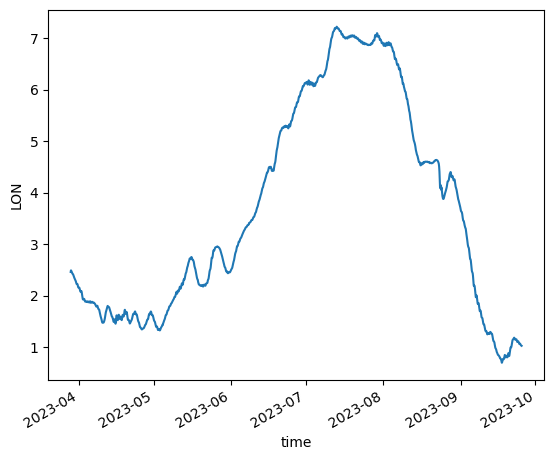

In [70]:
ds06.LON.plot()

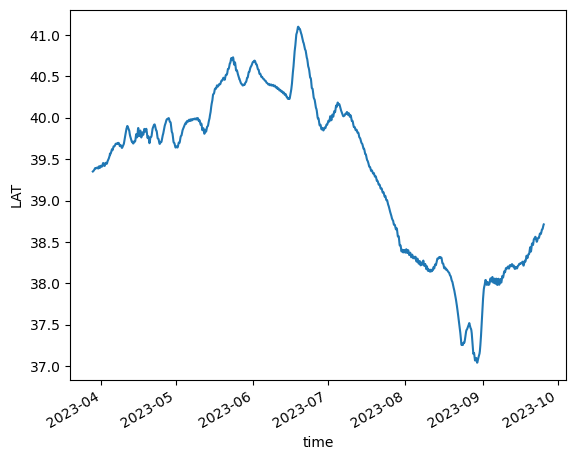

In [71]:
ds06.LAT.plot()

## 2.6. Recalculate U and V:

In [72]:
_, ufor, vfor    = latlon2uv_dir(ds06['LAT'], ds06['LON'], temp_res, 'for') # 600 = temporal resolution
_, uback, vback  = latlon2uv_dir(ds06['LAT'], ds06['LON'], temp_res, 'back')

In [73]:
# Calculate central value
u = (ufor + uback) / 2
v = (vfor + vback) / 2

In [74]:
ds = ds06.copy()

In [75]:
# Add variables to the dataset
ds = ds.assign(U=(ufor+uback)*0.5)
ds = ds.assign(V=(vfor+vback)*0.5)
# ds06 = ds06.assign(UV=(uvabsfor+uvabsback)*0.5)
print(list(ds.keys()))

['LAT', 'LON', 'sst', 'slp', 'U', 'V']


# Comparing abs. vel before and after smoothing:

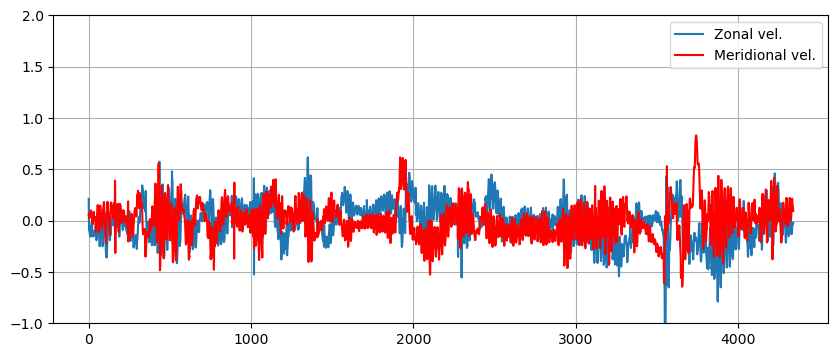

In [76]:
# Limit y axis to see velocity time series
plt.figure(figsize=(10,4))
plt.plot(u, label='Zonal vel.')
plt.plot(v, 'r', label='Meridional vel.')
plt.ylim(-1,2)
plt.legend()
plt.grid()

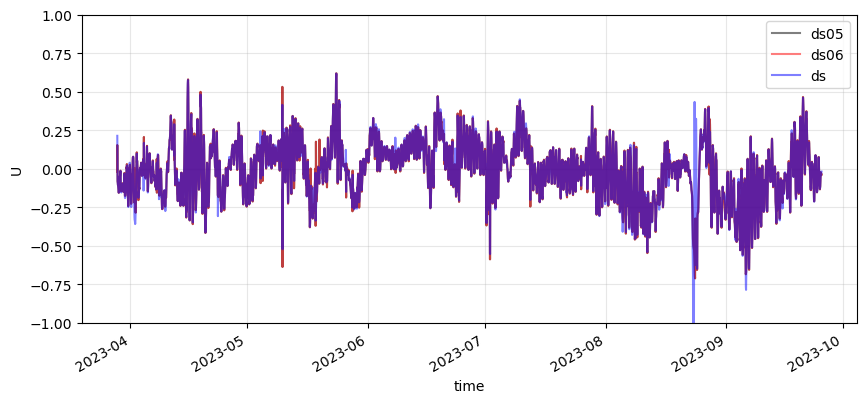

In [77]:
# Limit y axis to see velocity time series
plt.figure(figsize=(10,4))
ds05.U.plot(alpha = 0.5, color = "k", label='ds05');
ds06.U.plot(alpha = 0.5, color = "r", label='ds06');
ds.U.plot(alpha = 0.5, color = "b", label='ds');
plt.ylim(-1, 1)
plt.grid(alpha=0.3)
plt.legend()

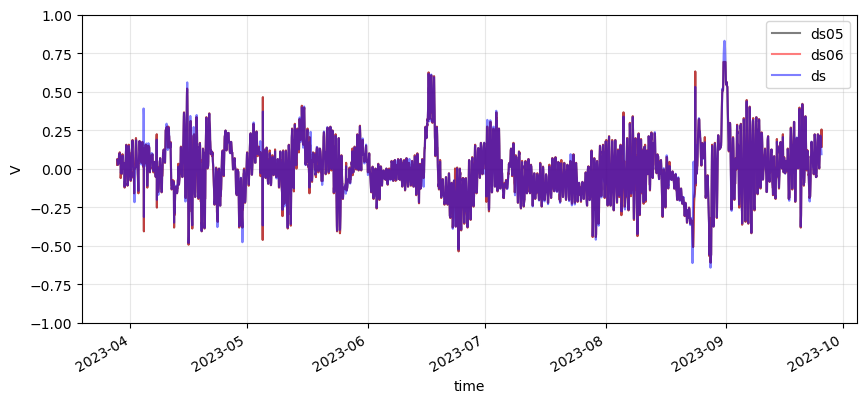

In [78]:
# Limit y axis to see velocity time series
plt.figure(figsize=(10,4))
ds05.V.plot(alpha = 0.5, color = "k", label='ds05');
ds06.V.plot(alpha = 0.5, color = "r", label='ds06');
ds.V.plot(alpha = 0.5, color = "b", label='ds');
plt.ylim(-1,1)
plt.grid(alpha=0.3)
plt.legend()

https://thredds.socib.es/thredds/dodsC/drifter/surface_drifter/drifter_carthe036-scb_carthe017/L0/2023/dep0001_drifter-carthe036_scb-carthe017_L0_2023-09-07.nc.html

0 = Low battery, 1 = good

# --> well cut already in terms of battery (in this case)

# Flags:

# --> later

# 3. Saving data

In [79]:
rootdir = '../../../../../'

In [80]:
outdir = 'data/drifters/L1_IMEDEA/'

In [81]:
#  Renaming as no longer using SOCIB's L0
outname = url_drifter.split('/')[-1][0:-1].replace('L0', 'L1').replace('scb', 'ime') #outname
# --> substitute L0 by L1 and scb by ime. [0:-1], because last character in string is ?
outname = outname.split('_')[1]


## Copying attributes of SOCIB dataset to this one:

In [82]:
ds.attrs = ds_url.attrs

## Saving to netcdf:

In [83]:
savefile = rootdir + outdir + outname + '.nc'

### Checking first if ile already exists:

In [84]:
if os.path.exists(savefile):
    # Replace the file or do whatever operation you need
    os.remove(savefile)  # Delete the existing file, if you want to replace it completely
    # Here you can create a new file or copy a template file, etc.
    print(f"{savefile} exists and has been replaced.")
else:
    print(f"{savefile} does not exist.")

../../../../../data/drifters/L1_IMEDEA/drifter-svpb035.nc exists and has been replaced.


### Saving:

In [85]:
ds.to_netcdf(savefile)

In [86]:
!ls ../../../../../data/drifters/L1_IMEDEA/

dep0001_drifter-svpb039_ime-svpb039_L1_2023-04-26.nc
drifter-svpb035.nc
drifter-svpb038.nc
drifter-svpb039.nc
drifter-svpb040.nc
drifter-svpb041.nc
drifter-svpb042.nc
drifter_carthe006-ime_carthe001.nc
drifter_carthe007-ime_carthe002.nc
drifter_carthe008-ime_carthe003.nc
drifter_carthe009-ime_carthe004.nc
drifter_carthe010-ime_carthe005.nc
drifter_carthe011-ime_carthe006.nc
drifter_carthe012-ime_carthe007.nc
drifter_carthe013-ime_carthe008.nc
drifter_carthe014-ime_carthe009.nc
drifter_carthe015-ime_carthe010.nc
drifter_carthe016-ime_carthe011.nc
drifter_carthe017-ime_carthe012.nc
drifter_carthe018-ime_carthe013.nc
drifter_carthe019-ime_carthe014.nc
drifter_carthe020-ime_carthe015.nc
drifter_carthe021-ime_carthe016.nc
drifter_carthe022-ime_carthe017.nc
drifter_carthe023-ime_carthe018.nc
drifter_carthe024-ime_carthe019.nc
drifter_carthe025-ime_carthe020.nc
drifter_hereon001-ime_hereon001.nc
drifter_hereon002-ime_hereon002.nc
drifter_hereon003-ime_hereon003.nc
drifter_hereon004-ime_hereon

# 4. Plotting outputs

In [89]:
map_extent=[-0.3, 7.9, 37., 41.5]
fsize=14


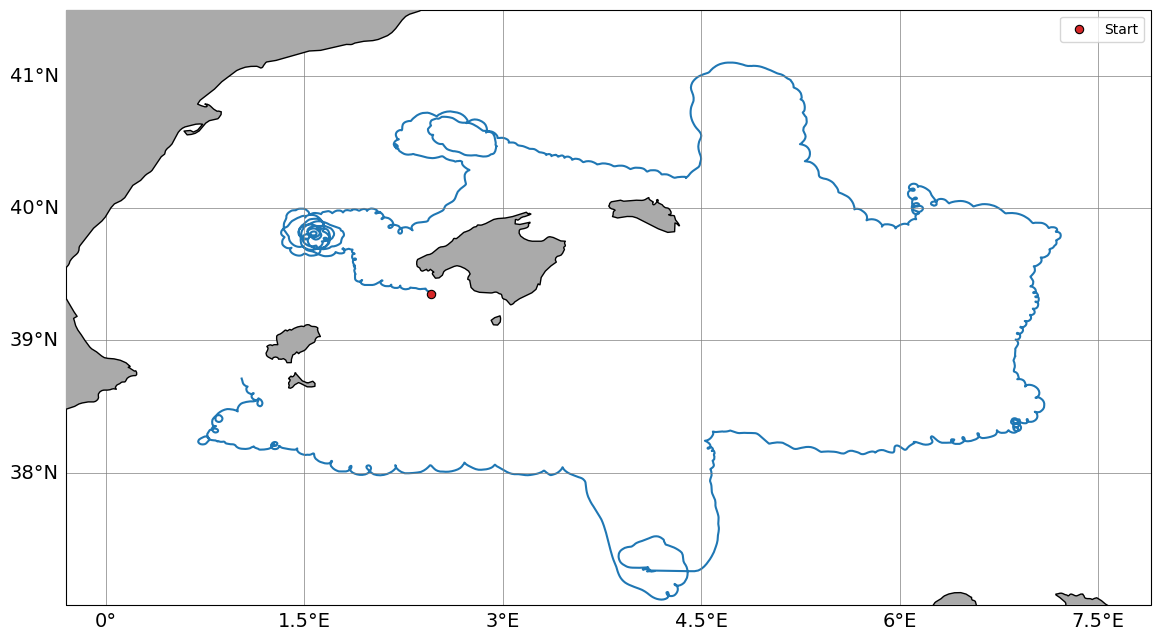

In [90]:
fig = plt.figure(figsize=(14,8))

ax1 = plt.subplot(111, projection=ccrs.PlateCarree())


#############
# Land
feature = cartopy.feature.NaturalEarthFeature(name='coastline', category='physical',
                                              scale='10m', zorder=10,
                                              edgecolor='black', facecolor='#AAAAAA')
ax1.add_feature(feature)
#############
# Grid and ticks
gl = ax1.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                  linewidth=0.5, color='gray', linestyle='-') #, alpha=0.5

gl.top_labels = False
gl.right_labels = False

gl.xlabel_style = {'size': fsize}#, 'color': 'gray'}
gl.ylabel_style = {'size': fsize}#, 'color': 'gray'}
#############

ax1.plot(ds.LON, ds.LAT, transform=ccrs.PlateCarree(), c='C0') 
ax1.scatter(ds.LON[0], ds.LAT[0], c='C3', edgecolor='k', linewidths=0.8, transform=ccrs.PlateCarree(), label='Start', zorder=50)

ax1.set_extent(map_extent, crs=ccrs.PlateCarree())
ax1.legend()
# ax1.set_title('Trajectory of ' + ds.attrs['title'].split(' ')[3].split('-')[-1], size=fsize+2) 

outname = url_drifter.split('/')[-1][0:-1].replace('L0', 'L1').replace('scb', 'ime') #outname
# --> substitute L0 by L1 and scb by ime. [0:-1], because last character in string is ?
outname = outname.split('_')[1]

plt.savefig(savedir_figs + 'traj_proc_' + outname + '.png', dpi=300)

plt.show()

## Velocity:

In [91]:
thresa = .1
map_extent = [ds.LON.min().values - thresa, ds.LON.max().values + thresa, ds.LAT.min().values - thresa, ds.LAT.max().values + thresa]

In [92]:
abs_vel = (ds.U**2 + ds.V**2)**0.5

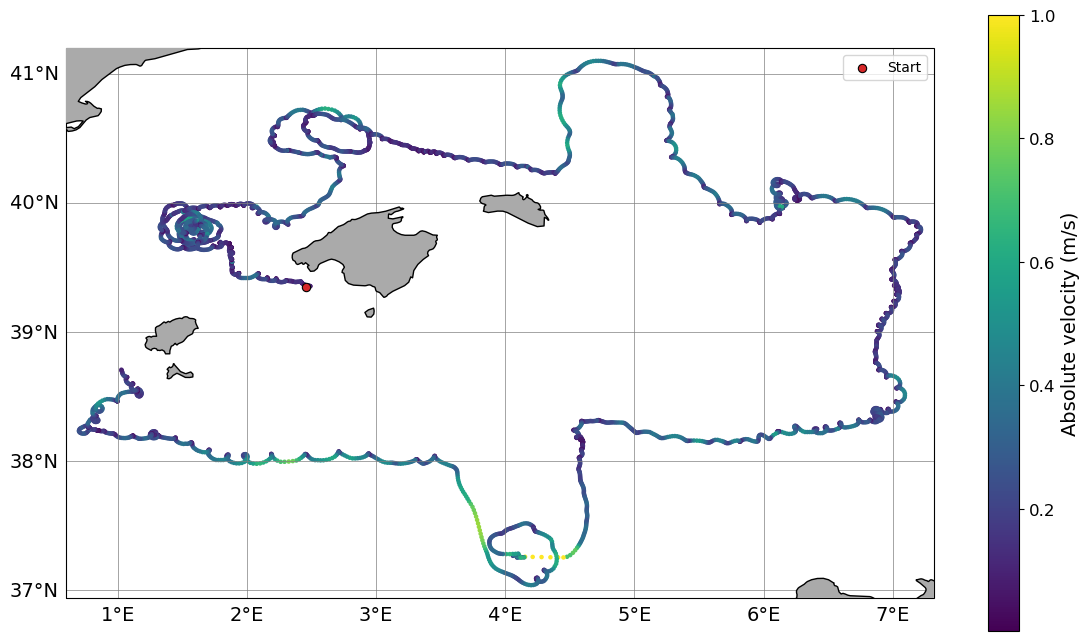

In [95]:
fig = plt.figure(figsize=(14,8))

ax1 = plt.subplot(111, projection=ccrs.PlateCarree())


#############
# Land
feature = cartopy.feature.NaturalEarthFeature(name='coastline', category='physical',
                                              scale='10m', zorder=10,
                                              edgecolor='black', facecolor='#AAAAAA')
ax1.add_feature(feature)
#############
# Grid and ticks
gl = ax1.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                  linewidth=0.5, color='gray', linestyle='-') #, alpha=0.5

gl.top_labels = False
gl.right_labels = False

gl.xlabel_style = {'size': fsize}#, 'color': 'gray'}
gl.ylabel_style = {'size': fsize}#, 'color': 'gray'}
#############

cc = ax1.scatter(ds.LON, ds.LAT, s=5, c=abs_vel, vmax=1., transform=ccrs.PlateCarree())
ax1.scatter(ds.LON[0], ds.LAT[0], c='C3', edgecolor='k', linewidths=0.8, transform=ccrs.PlateCarree()
            , label='Start')
cbar = plt.colorbar(cc)
cbar_label = r'Absolute velocity (m/s)'
cbar.ax.tick_params(labelsize=fsize-2)
cbar.ax.set_ylabel(cbar_label, fontsize=fsize)

ax1.set_extent(map_extent, crs=ccrs.PlateCarree())
ax1.legend()
# ax1.set_title(ds05.attrs['title'].split(' ')[3].split('-')[-1], size=fsize+2) 

outname = url_drifter.split('/')[-1][0:-1].replace('L0', 'L1').replace('scb', 'ime') #outname
# --> substitute L0 by L1 and scb by ime. [0:-1], because last character in string is ?
outname = outname.split('_')[1]

plt.savefig(savedir_figs + 'traj_proc_vels_' + outname + '.png', dpi=300)

plt.show()